# 基于物理先验的神经网络优化 Arrhenius 本构方程（指标优化版）

本版本在尽量保持原始流程与图片输出一致的前提下，针对 1010°C 外推 AARE 偏高的问题做两类优化：

- **数据处理更稳健**：插值由 `CubicSpline` 改为形状保持的 `PCHIP`，降低低应力段的过冲/振荡。
- **对 AARE 更友好的建模与评估**：
  - NN 训练目标改为 `log(σ)`（等价于强调相对误差，通常能显著降低 AARE）。
  - 评估时增加“工程常用”的有效区间与分母下限（避免低应力点导致 AARE 虚高），并同时保留原始 AARE 供对照。

> 输出图片的风格、命名与原版基本一致，但会保存到单独目录，避免覆盖原结果。

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from scipy.interpolate import PchipInterpolator
from scipy.stats import linregress

import warnings, copy, os, random
from datetime import datetime
import re
warnings.filterwarnings('ignore')

# ==================== 统一图表样式配置（保持与原版一致） ====================
plt.rcParams.update({
    'font.sans-serif': ['Arial Unicode MS', 'SimHei', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})


METHOD_COLORS = {
    'Arrhenius':         '#1f77b4',
    'NN-Direct':         '#ff7f0e',
    'NN-Arrhenius-Only': '#7f7f7f',
    'NN-PhysicsInit':    '#d62728',
}
METHOD_STYLES = {
    'Arrhenius': '--', 'NN-Direct': '-.',
    'NN-Arrhenius-Only': ':', 'NN-PhysicsInit': '-',
}
METHOD_MARKERS = {
    'Arrhenius': 's', 'NN-Direct': '^',
    'NN-Arrhenius-Only': 'D', 'NN-PhysicsInit': 'o',
}
BAR_COLORS = ['#1f77b4', '#ff7f0e', '#7f7f7f', '#d62728']
METHOD_ORDER = ['Arrhenius', 'NN-Direct', 'NN-Arrhenius-Only', 'NN-PhysicsInit']

FIG_DIR = os.path.join(r'/Users/bertonyang/project/chenglu/data_processor', r'4神经网络优化Arrhenius_指标优化')
os.makedirs(FIG_DIR, exist_ok=True)
print(f'Figure output directory: {FIG_DIR}')

def _next_available_path(path):
    if not os.path.exists(path):
        return path
    base, ext = os.path.splitext(path)
    idx = 2
    while True:
        cand = f'{base}_v{idx}{ext}'
        if not os.path.exists(cand):
            return cand
        idx += 1

def _safe_figure_name(name):
    name = str(name)
    name = re.sub(r'[^A-Za-z0-9._\-+()\[\]{} ]+', ' ', name)
    name = re.sub(r'\s+', '_', name).strip('_')
    return name if name else 'figure'


def save_fig(fig, name):
    safe_name = _safe_figure_name(name)
    raw_path = os.path.join(FIG_DIR, f'{safe_name}.png')
    path = _next_available_path(raw_path)
    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {path}')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

R_GAS = 8.314
TRAIN_TEMPS = [800, 850, 900, 950, 980]
TEST_TEMPS  = [1010]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}, device: {device}')

# ==================== 指标优化参数（新增） ====================
# 1) 评估有效区间：排除低应力/低应变点对 AARE 的放大效应
#    说明：1010°C 外推集中存在 10MPa 级别的低应力点，AARE=|e|/σ 会被这些点显著放大。
EVAL_STRAIN_MIN = 0.10
EVAL_STRESS_MIN_MPA = 15.0
AARE_DENOM_FLOOR_MPA = 20.0

# 2) NN 训练：对相对误差更友好
USE_LOG_STRESS_TARGET = True

# 3) 插值：使用形状保持插值，减少过冲
INTERP_KIND = 'PCHIP'

Figure output directory: /Users/bertonyang/project/chenglu/data_processor/4神经网络优化Arrhenius_指标优化
PyTorch 2.2.2, device: cpu


---
## 1. 数据加载与训练/测试划分（与原版一致）

In [32]:
file_path = '/Users/bertonyang/project/chenglu/data/TC4_0219.xlsx'

xlsx = pd.ExcelFile(file_path)
all_data = []
for sheet_name in xlsx.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)
    temp = int(sheet_name)
    num_pairs = df.shape[1] // 2
    for i in range(num_pairs):
        strain_rate = float(df.iloc[0, i * 2])
        strain = pd.to_numeric(df.iloc[1:, i * 2], errors='coerce')
        stress = pd.to_numeric(df.iloc[1:, i * 2 + 1], errors='coerce')
        for s_val, r_val in zip(strain, stress):
            if pd.notna(s_val) and pd.notna(r_val):
                all_data.append({
                    'Temperature': temp,
                    'T_K': temp + 273.15,
                    'StrainRate': strain_rate,
                    'TrueStrain': float(s_val),
                    'FlowStress': float(r_val),
                })

df_all = pd.DataFrame(all_data)
# 原版只做了 >0 过滤，这里保持一致（更强的筛选放在评估/训练阶段）
df_all = df_all[(df_all['FlowStress'] > 0) & (df_all['TrueStrain'] > 0)].copy()

df_train_raw = df_all[df_all['Temperature'].isin(TRAIN_TEMPS)].copy()
df_test_raw  = df_all[df_all['Temperature'].isin(TEST_TEMPS)].copy()

print(f'全部数据: {len(df_all)} 条')
print(f'训练集 ({TRAIN_TEMPS}): {len(df_train_raw)} 条')
print(f'测试集 ({TEST_TEMPS}): {len(df_test_raw)} 条')
print(f'应变速率: {sorted(df_all["StrainRate"].unique())}')

全部数据: 39109 条
训练集 ([800, 850, 900, 950, 980]): 33109 条
测试集 ([1010]): 6000 条
应变速率: [np.float64(0.001), np.float64(0.01), np.float64(0.1), np.float64(1.0), np.float64(10.0)]


In [33]:
# 形状保持插值（PCHIP）→ 离散应变点（与原版 strain_targets 保持一致）
strain_targets = np.arange(0.05, 0.705, 0.05)
rates = sorted(df_all['StrainRate'].unique())


def interpolate_stress_pchip(df_zone, temps_list, strain_targets):
    rows = []
    for temp in temps_list:
        for sr in rates:
            sub = df_zone[(df_zone['Temperature'] == temp) & (df_zone['StrainRate'] == sr)].sort_values('TrueStrain')
            grp = sub.groupby('TrueStrain')['FlowStress'].mean().reset_index()
            if len(grp) < 4:
                continue
            x = grp['TrueStrain'].values
            y = grp['FlowStress'].values
            # PCHIP 对单调/局部形状更稳健，避免三次样条过冲
            try:
                interp = PchipInterpolator(x, y, extrapolate=False)
                for eps in strain_targets:
                    if x.min() <= eps <= x.max():
                        sigma = float(interp(eps))
                        if np.isfinite(sigma) and sigma > 0:
                            rows.append({
                                'Temperature': temp,
                                'T_K': temp + 273.15,
                                'StrainRate': sr,
                                'TrueStrain': round(float(eps), 4),
                                'FlowStress': sigma,
                            })
            except Exception:
                pass
    return pd.DataFrame(rows)


df_train = interpolate_stress_pchip(df_train_raw, TRAIN_TEMPS, strain_targets)
df_test  = interpolate_stress_pchip(df_test_raw,  TEST_TEMPS,  strain_targets)

print(f'训练集（插值后）: {len(df_train)} 点, 覆盖 {df_train["Temperature"].nunique()} 个温度 × {df_train["StrainRate"].nunique()} 个速率 × {df_train["TrueStrain"].nunique()} 个应变')
print(f'测试集（插值后）: {len(df_test)} 点')
print(f'\n训练集应力范围: [{df_train["FlowStress"].min():.1f}, {df_train["FlowStress"].max():.1f}] MPa')
print(f'测试集应力范围: [{df_test["FlowStress"].min():.1f}, {df_test["FlowStress"].max():.1f}] MPa')

训练集（插值后）: 325 点, 覆盖 5 个温度 × 5 个速率 × 14 个应变
测试集（插值后）: 65 点

训练集应力范围: [12.5, 390.9] MPa
测试集应力范围: [9.7, 90.2] MPa


---
## 2. 传统全局 Arrhenius 模型拟合（仅训练集）

保持原版参数求解逻辑，后续用于：
- 作为基线方法（Arrhenius）
- 生成合成数据用于 NN 预训练（PhysicsInit）

In [34]:
def solve_arrhenius_params(df_disc, temps_list, rates_list, strain_targets):
    """全局（不分段）Arrhenius 参数求解"""
    results = {}
    for eps in strain_targets:
        eps_r = round(float(eps), 4)
        sub = df_disc[np.isclose(df_disc['TrueStrain'], eps_r)]
        if len(sub) < 4:
            continue

        # n1: slope of ln(ε̇) vs ln(σ) at each T
        n1_slopes = []
        for t in temps_list:
            g = sub[sub['Temperature'] == t]
            if len(g) >= 2:
                s, _, _, _, _ = linregress(np.log(g['FlowStress']), np.log(g['StrainRate']))
                n1_slopes.append(s)

        # β: slope of ln(ε̇) vs σ at each T
        beta_slopes = []
        for t in temps_list:
            g = sub[sub['Temperature'] == t]
            if len(g) >= 2:
                s, _, _, _, _ = linregress(g['FlowStress'], np.log(g['StrainRate']))
                beta_slopes.append(s)

        if not n1_slopes or not beta_slopes:
            continue

        n1 = float(np.mean(n1_slopes))
        beta = float(np.mean(beta_slopes))
        alpha = beta / n1

        # n: slope of ln(ε̇) vs ln[sinh(ασ)] at each T
        n_slopes = []
        for t in temps_list:
            g = sub[sub['Temperature'] == t]
            if len(g) >= 2:
                x = np.log(np.sinh(alpha * g['FlowStress'].values))
                y = np.log(g['StrainRate'].values)
                if np.all(np.isfinite(x)):
                    s, _, _, _, _ = linregress(x, y)
                    n_slopes.append(s)

        if not n_slopes:
            continue

        n_val = float(np.mean(n_slopes))

        # Q: slope of ln[sinh(ασ)] vs 1/T at each strain rate
        S_slopes = []
        for sr in rates_list:
            g = sub[sub['StrainRate'] == sr]
            if len(g) >= 2:
                x = 1.0 / g['T_K'].values
                y = np.log(np.sinh(alpha * g['FlowStress'].values))
                if np.all(np.isfinite(y)):
                    s, _, _, _, _ = linregress(x, y)
                    S_slopes.append(s)

        if not S_slopes:
            continue

        Q = float(R_GAS * n_val * np.mean(S_slopes))

        # lnA: intercept of lnZ vs ln[sinh(ασ)]
        sigma_all = sub['FlowStress'].values
        T_K_all = sub['T_K'].values
        sr_all = sub['StrainRate'].values

        ln_Z = np.log(sr_all) + Q / (R_GAS * T_K_all)
        x_all = np.log(np.sinh(alpha * sigma_all))
        valid = np.isfinite(ln_Z) & np.isfinite(x_all)

        if int(valid.sum()) >= 3:
            _, intercept, _, _, _ = linregress(x_all[valid], ln_Z[valid])
            results[eps_r] = {'alpha': alpha, 'n': n_val, 'Q': Q, 'lnA': float(intercept)}

    return results


arr_params = solve_arrhenius_params(df_train, TRAIN_TEMPS, rates, strain_targets)

# 多项式拟合（与原版一致：6次）
POLY_DEG = 6
eps_arr = np.array(sorted(arr_params.keys()), dtype=float)
poly_dict = {}
for key in ['alpha', 'n', 'Q', 'lnA']:
    vals = np.array([arr_params[e][key] for e in eps_arr], dtype=float)
    poly_dict[key] = np.polyfit(eps_arr, vals, POLY_DEG)

print(f'Arrhenius 参数求解完成: {len(arr_params)} 个应变点')
print(f'\n参数汇总:')
print(f'{"ε":>6s} {"α":>10s} {"n":>8s} {"Q(kJ/mol)":>12s} {"lnA":>10s}')
for e in eps_arr:
    p = arr_params[e]
    print(f'{e:>6.2f} {p["alpha"]:>10.6f} {p["n"]:>8.4f} {p["Q"]/1000:>12.2f} {p["lnA"]:>10.4f}')


def arrhenius_predict(epsilon, strain_rate, T_K, poly_dict):
    """Arrhenius 预测流变应力"""
    alpha = np.polyval(poly_dict['alpha'], epsilon)
    n_val = np.polyval(poly_dict['n'], epsilon)
    Q_val = np.polyval(poly_dict['Q'], epsilon)
    lnA = np.polyval(poly_dict['lnA'], epsilon)

    ln_Z = np.log(strain_rate) + Q_val / (R_GAS * T_K)
    x = np.exp((ln_Z - lnA) / n_val)
    sigma = (1.0 / alpha) * np.log(x + np.sqrt(x**2 + 1))
    return float(sigma)

Arrhenius 参数求解完成: 13 个应变点

参数汇总:
     ε          α        n    Q(kJ/mol)        lnA
  0.05   0.013680   3.1566       629.88    60.5632
  0.10   0.013692   3.1145       629.17    60.4797
  0.15   0.013434   3.0650       607.81    58.3508
  0.20   0.013708   3.0436       602.80    57.8022
  0.25   0.013665   3.0190       579.94    55.5503
  0.30   0.013807   2.9974       568.31    54.4134
  0.35   0.013924   3.0120       553.88    52.9946
  0.40   0.013851   3.0163       535.48    51.1985
  0.45   0.014102   3.0159       527.76    50.4314
  0.50   0.014152   3.0223       513.25    49.0077
  0.55   0.014249   3.0460       505.57    48.2731
  0.60   0.014366   3.0771       499.28    47.6481
  0.65   0.013679   3.1466       481.11    46.2010


---
## 3. 生成 Arrhenius 合成数据（用于物理先验预训练）

合成数据: 10000 条有效点（共生成 10000）
温度范围: [790, 1030] °C
应变速率范围: [0.0010, 9.99] s⁻¹
应变范围: [0.050, 0.650]
应力范围: [4.4, 350.1] MPa
  Saved: /Users/bertonyang/project/chenglu/data_processor/4神经网络优化Arrhenius_指标优化/synthetic_data_distribution_temperature_strain_rate_stress.png


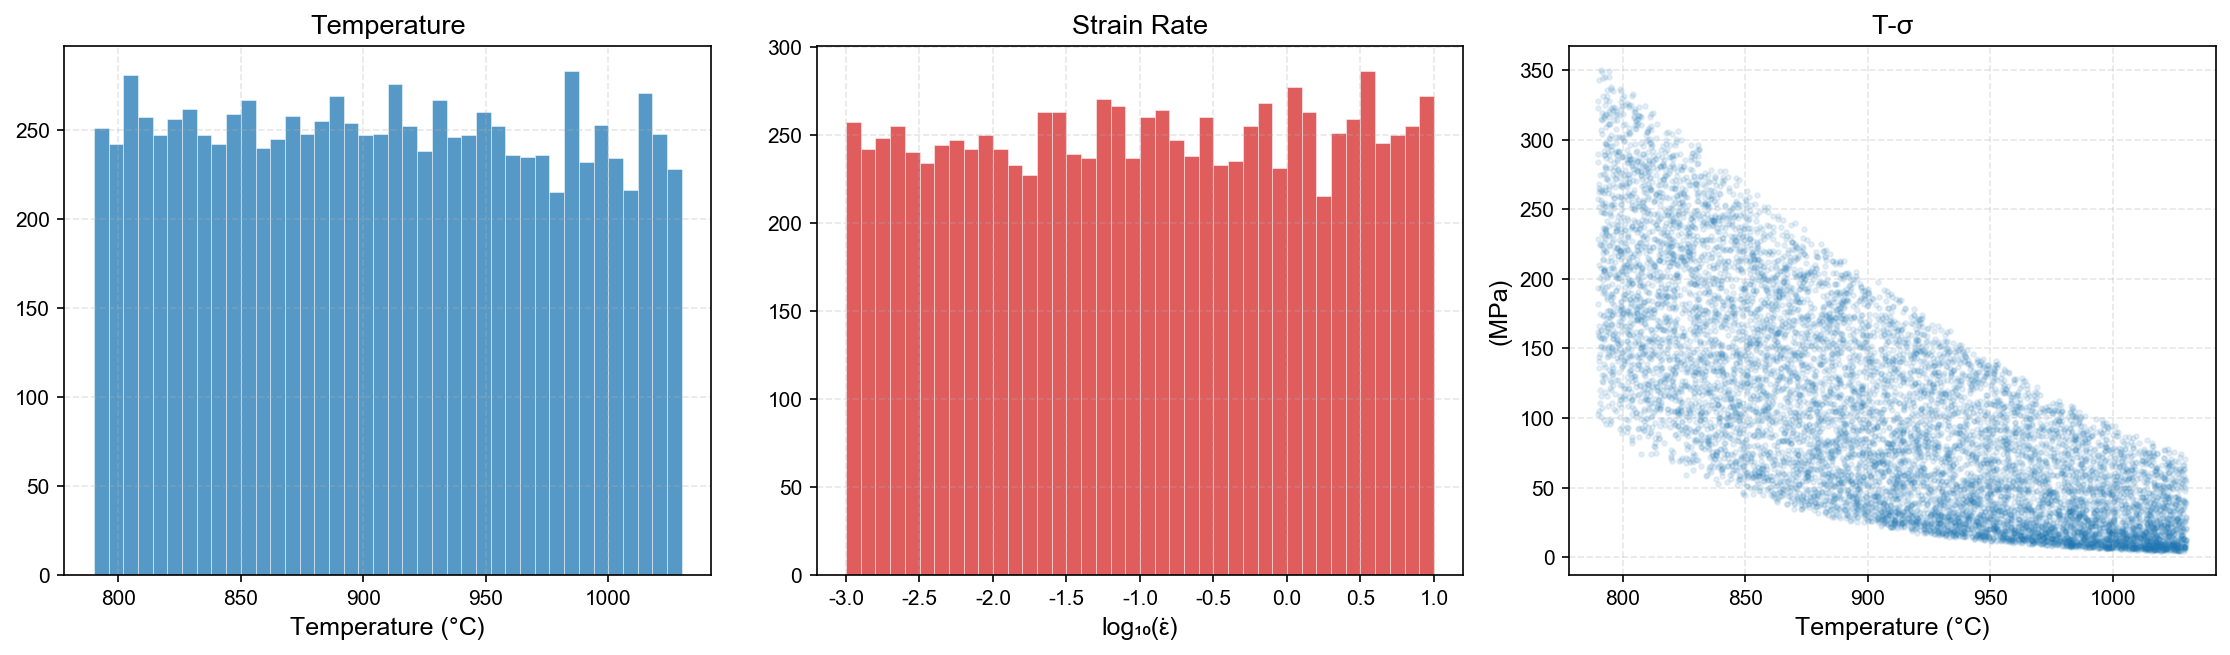

In [35]:
N_SYNTHETIC = 10000
T_min, T_max = 790, 1030
ln_sr_min, ln_sr_max = np.log(0.001), np.log(10)
eps_min, eps_max = float(eps_arr.min()), float(eps_arr.max())

syn_T_C = np.random.uniform(T_min, T_max, N_SYNTHETIC)
syn_T_K = syn_T_C + 273.15
syn_ln_sr = np.random.uniform(ln_sr_min, ln_sr_max, N_SYNTHETIC)
syn_sr = np.exp(syn_ln_sr)
syn_eps = np.random.uniform(eps_min, eps_max, N_SYNTHETIC)

syn_stress = np.array([
    arrhenius_predict(e, sr, tk, poly_dict)
    for e, sr, tk in zip(syn_eps, syn_sr, syn_T_K)
], dtype=float)

valid_syn = np.isfinite(syn_stress) & (syn_stress > 0) & (syn_stress < 600)
syn_T_C = syn_T_C[valid_syn]
syn_T_K = syn_T_K[valid_syn]
syn_sr = syn_sr[valid_syn]
syn_eps = syn_eps[valid_syn]
syn_stress = syn_stress[valid_syn]

print(f'合成数据: {len(syn_stress)} 条有效点（共生成 {N_SYNTHETIC}）')
print(f'温度范围: [{syn_T_C.min():.0f}, {syn_T_C.max():.0f}] °C')
print(f'应变速率范围: [{syn_sr.min():.4f}, {syn_sr.max():.2f}] s⁻¹')
print(f'应变范围: [{syn_eps.min():.3f}, {syn_eps.max():.3f}]')
print(f'应力范围: [{syn_stress.min():.1f}, {syn_stress.max():.1f}] MPa')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].hist(syn_T_C, bins=40, alpha=0.75, color=METHOD_COLORS['Arrhenius'], edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Temperature (°C)'); axes[0].set_title('Temperature')
axes[1].hist(np.log10(syn_sr), bins=40, alpha=0.75, color=METHOD_COLORS['NN-PhysicsInit'], edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('log₁₀(ε̇)'); axes[1].set_title('Strain Rate')
axes[2].scatter(syn_T_C, syn_stress, alpha=0.1, s=5, color=METHOD_COLORS['Arrhenius'])
axes[2].set_xlabel('Temperature (°C)'); axes[2].set_ylabel('(MPa)'); axes[2].set_title('T-σ')
plt.tight_layout()
save_fig(fig, 'synthetic_data_distribution_temperature_strain_rate_stress')
plt.show()

---
## 4. 神经网络定义与训练工具（相对误差友好）

- 输入特征：`[1000/T, ln(ε̇), ε]`（更贴近 Arrhenius 的 1/T 形式）
- 训练目标：默认 `log(σ)`，通常能显著降低 AARE

In [36]:
class StressNet(nn.Module):
    def __init__(self, hidden_dims=(128, 128, 64)):
        super().__init__()
        layers = []
        in_dim = 3
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.SiLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class Normalizer:
    """Z-score 标准化（支持 1D / 2D numpy array）"""
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, data):
        data = np.asarray(data)
        self.mean = data.mean(axis=0)
        self.std = data.std(axis=0)
        self.std = np.where(self.std < 1e-8, 1.0, self.std)
        return self

    def transform(self, data):
        data = np.asarray(data)
        return (data - self.mean) / self.std

    def inverse_transform(self, data):
        data = np.asarray(data)
        return data * self.std + self.mean


def prepare_features(df_or_arrays, is_arrays=False):
    """构建特征矩阵 [1000/T_K, ln(SR), strain]"""
    if is_arrays:
        T_K, SR, EPS = df_or_arrays
    else:
        T_K = df_or_arrays['T_K'].values
        SR = df_or_arrays['StrainRate'].values
        EPS = df_or_arrays['TrueStrain'].values

    T_feat = 1000.0 / np.asarray(T_K, dtype=float)
    ln_sr = np.log(np.asarray(SR, dtype=float))
    eps = np.asarray(EPS, dtype=float)
    return np.column_stack([T_feat, ln_sr, eps])


def _to_numpy_1d(t: torch.Tensor) -> np.ndarray:
    return np.array(t.detach().cpu().reshape(-1).tolist(), dtype=float)


def train_model(model, X_train, y_train, *, epochs=800, lr=1e-3, batch_size=256,
                X_val=None, y_val=None, verbose_every=200, patience=120):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()

    X_t = torch.FloatTensor(X_train).to(device)
    y_t = torch.FloatTensor(y_train).reshape(-1, 1).to(device)
    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    history = {'train_loss': [], 'val_loss': []}
    model.to(device)

    best_state = None
    best_val = float('inf')
    bad = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += float(loss.item()) * len(xb)
        scheduler.step()

        train_loss = total_loss / len(X_train)
        history['train_loss'].append(train_loss)

        val_loss = None
        if X_val is not None:
            model.eval()
            with torch.no_grad():
                vp = model(torch.FloatTensor(X_val).to(device))
                val_loss = float(criterion(vp, torch.FloatTensor(y_val).reshape(-1, 1).to(device)).item())
            history['val_loss'].append(val_loss)

            if val_loss + 1e-10 < best_val:
                best_val = val_loss
                best_state = copy.deepcopy(model.state_dict())
                bad = 0
            else:
                bad += 1
                if patience and bad >= patience:
                    break

        if verbose_every and (epoch + 1) % verbose_every == 0:
            if val_loss is not None:
                print(f'Epoch {epoch+1:>4d}/{epochs}: train={train_loss:.6e}, val={val_loss:.6e}')
            else:
                print(f'Epoch {epoch+1:>4d}/{epochs}: train={train_loss:.6e}')

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


def predict_nn(model, X, norm_X: Normalizer, norm_y: Normalizer):
    Xn = norm_X.transform(X)
    model.eval()
    with torch.no_grad():
        pred_norm = model(torch.FloatTensor(Xn).to(device))
    pred_norm_np = _to_numpy_1d(pred_norm)
    pred_space = norm_y.inverse_transform(pred_norm_np)
    if USE_LOG_STRESS_TARGET:
        return np.exp(pred_space)
    return pred_space

---
## 5. 三种 NN 方法训练（Direct / Arrhenius-Only / PhysicsInit）

In [37]:
# 真实离散点训练数据
X_train_real = prepare_features(df_train)
y_train_real = df_train['FlowStress'].values.astype(float)

X_test = prepare_features(df_test)
y_test = df_test['FlowStress'].values.astype(float)

def make_target(y):
    y = np.asarray(y, dtype=float)
    if USE_LOG_STRESS_TARGET:
        return np.log(np.clip(y, 1e-6, None))
    return y

y_train_tgt = make_target(y_train_real)
y_test_tgt = make_target(y_test)

# 合成数据
X_syn = prepare_features((syn_T_K, syn_sr, syn_eps), is_arrays=True)
y_syn = syn_stress.astype(float)
y_syn_tgt = make_target(y_syn)

# Normalizer：覆盖（合成 + 真实）范围
norm_X = Normalizer().fit(np.vstack([X_syn, X_train_real]))
norm_y = Normalizer().fit(np.concatenate([y_syn_tgt, y_train_tgt]))

X_syn_norm = norm_X.transform(X_syn)
y_syn_norm = (y_syn_tgt - norm_y.mean) / norm_y.std

X_train_real_norm = norm_X.transform(X_train_real)
y_train_real_norm = (y_train_tgt - norm_y.mean) / norm_y.std

# 简单随机划分一个验证集（用于早停）
idx = np.arange(len(X_train_real_norm))
np.random.shuffle(idx)
split = int(len(idx) * 0.85)
tr_idx, va_idx = idx[:split], idx[split:]

X_tr, y_tr = X_train_real_norm[tr_idx], y_train_real_norm[tr_idx]
X_va, y_va = X_train_real_norm[va_idx], y_train_real_norm[va_idx]

print(f'Real train points: {len(X_train_real_norm)} (train={len(tr_idx)}, val={len(va_idx)})')
print(f'Synthetic points : {len(X_syn_norm)}')
print(f'USE_LOG_STRESS_TARGET={USE_LOG_STRESS_TARGET}')

Real train points: 325 (train=276, val=49)
Synthetic points : 10000
USE_LOG_STRESS_TARGET=True


===== NN-Direct: Real-only training =====
Epoch  200/900: train=8.652909e-03, val=1.137240e-02
Epoch  400/900: train=3.699804e-03, val=6.185092e-03
Epoch  600/900: train=2.154446e-03, val=2.878163e-03
Epoch  800/900: train=2.029078e-03, val=2.511729e-03
===== NN-Arrhenius-Only: Synthetic-only pretraining =====
Epoch  200/700: train=2.502845e-05
Epoch  400/700: train=1.660766e-05
Epoch  600/700: train=1.277761e-05
===== NN-PhysicsInit: Phase 1 (Synthetic pretraining) =====
Epoch  200/700: train=2.709366e-05
Epoch  400/700: train=2.259146e-05
Epoch  600/700: train=1.577659e-05
===== NN-PhysicsInit: Phase 2 (Real finetune) =====
Epoch  200/900: train=1.135032e-02, val=1.291765e-02
Epoch  400/900: train=9.745425e-03, val=1.130536e-02
Epoch  600/900: train=8.195513e-03, val=1.077051e-02
Epoch  800/900: train=7.643660e-03, val=9.885970e-03
  Saved: /Users/bertonyang/project/chenglu/data_processor/4神经网络优化Arrhenius_指标优化/training_curves_loss_comparison_three_nn_methods.png


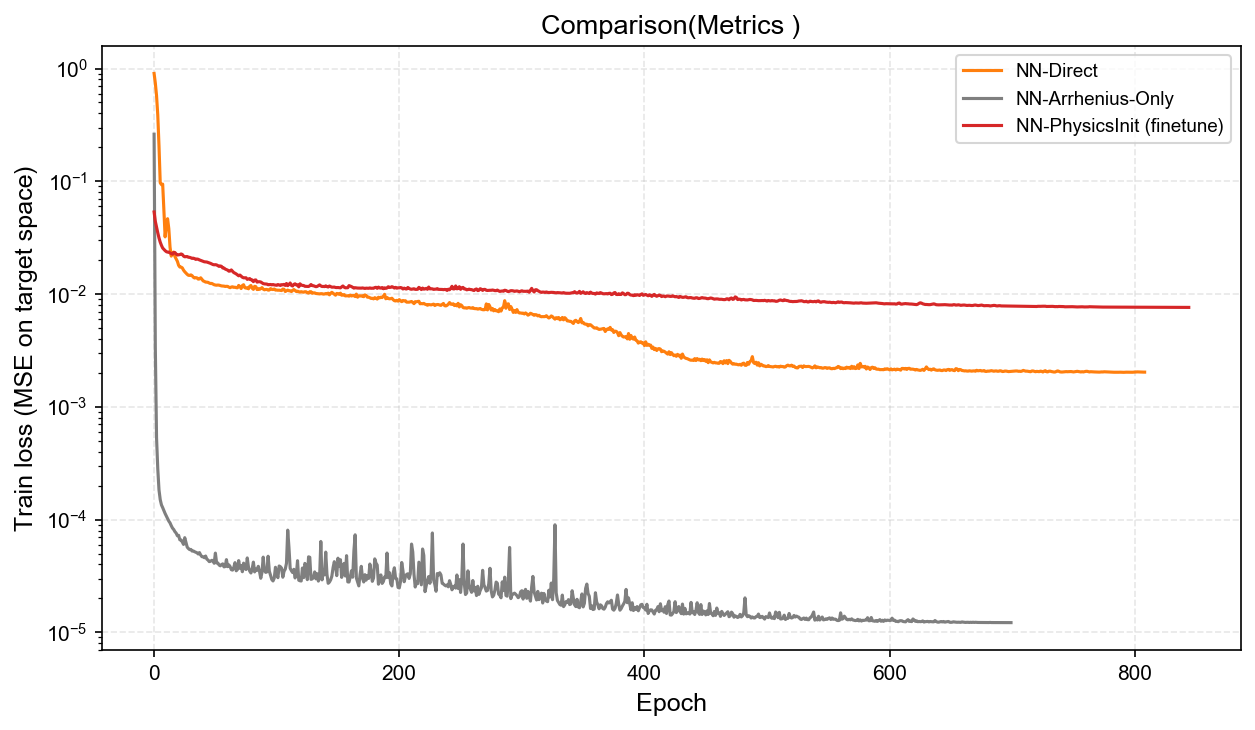

In [38]:
EPOCHS_PRE = 700
EPOCHS_REAL = 900
VERBOSE_EVERY = 200

# ===== NN-Direct: 仅真实数据训练 =====
model_direct = StressNet().to(device)
print('===== NN-Direct: Real-only training =====')
hist_direct = train_model(
    model_direct, X_tr, y_tr,
    X_val=X_va, y_val=y_va,
    epochs=EPOCHS_REAL, lr=1e-3, batch_size=128,
    verbose_every=VERBOSE_EVERY, patience=180,
)

# ===== NN-Arrhenius-Only: 仅合成数据训练 =====
model_arrhenius_only = StressNet().to(device)
print('===== NN-Arrhenius-Only: Synthetic-only pretraining =====')
hist_arronly = train_model(
    model_arrhenius_only, X_syn_norm, y_syn_norm,
    epochs=EPOCHS_PRE, lr=1e-3, batch_size=256,
    verbose_every=VERBOSE_EVERY, patience=160,
)

# ===== NN-PhysicsInit: 先合成预训练，再真实微调 =====
model_physics = StressNet().to(device)
print('===== NN-PhysicsInit: Phase 1 (Synthetic pretraining) =====')
hist_phy_pre = train_model(
    model_physics, X_syn_norm, y_syn_norm,
    epochs=EPOCHS_PRE, lr=1e-3, batch_size=256,
    verbose_every=VERBOSE_EVERY, patience=160,
)
print('===== NN-PhysicsInit: Phase 2 (Real finetune) =====')
hist_phy_ft = train_model(
    model_physics, X_tr, y_tr,
    X_val=X_va, y_val=y_va,
    epochs=EPOCHS_REAL, lr=5e-4, batch_size=128,
    verbose_every=VERBOSE_EVERY, patience=220,
)

# 训练曲线对比（保持原版输出风格）
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(hist_direct['train_loss'], label='NN-Direct', color=METHOD_COLORS['NN-Direct'])
ax.plot(hist_arronly['train_loss'], label='NN-Arrhenius-Only', color=METHOD_COLORS['NN-Arrhenius-Only'])
ax.plot(hist_phy_ft['train_loss'], label='NN-PhysicsInit (finetune)', color=METHOD_COLORS['NN-PhysicsInit'])
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Train loss (MSE on target space)')
ax.set_title('Comparison(Metrics )')
ax.legend(loc='best')
plt.tight_layout()
save_fig(fig, 'training_curves_loss_comparison_three_nn_methods')
plt.show()

---
## 6. 指标评估（稳健 AARE + 原始 AARE 对照）

- **原始 AARE**：`|pred-true|/true`（低应力点会放大）
- **稳健 AARE（用于主表）**：
  - 仅统计 `ε ≥ EVAL_STRAIN_MIN`
  - 分母使用 `max(true, AARE_DENOM_FLOOR_MPA)`

In [39]:
def evaluate_method(name, y_true, y_pred, eps=None,
                    *, strain_min=EVAL_STRAIN_MIN, denom_floor=AARE_DENOM_FLOOR_MPA,
                    stress_min=EVAL_STRESS_MIN_MPA):
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)

    valid = np.isfinite(yt) & np.isfinite(yp) & (yp > 0) & (yt > 0)
    valid = valid & (yt >= float(stress_min))
    if eps is not None:
        eps = np.asarray(eps, dtype=float)
        valid = valid & (eps >= strain_min)

    yt_v = yt[valid]
    yp_v = yp[valid]

    R = float(np.corrcoef(yt_v, yp_v)[0, 1]) if len(yt_v) >= 2 else np.nan

    # 原始 AARE（仅用于对照）
    AARE_raw = float((np.abs(yp_v - yt_v) / yt_v * 100.0).mean())

    # 稳健 AARE：分母下限
    denom = np.maximum(yt_v, float(denom_floor))
    AARE = float((np.abs(yp_v - yt_v) / denom * 100.0).mean())

    RMSE = float(np.sqrt(np.mean((yp_v - yt_v) ** 2)))

    return {
        '方法': name,
        'R': R,
        'R²': R**2 if np.isfinite(R) else np.nan,
        'AARE_raw(%)': AARE_raw,
        'AARE(%)': AARE,
        'RMSE(MPa)': RMSE,
        'N': int(len(yt_v)),
    }


# Arrhenius predictions
arr_pred_train = np.array([
    arrhenius_predict(r['TrueStrain'], r['StrainRate'], r['T_K'], poly_dict)
    for _, r in df_train.iterrows()
], dtype=float)
arr_pred_test = np.array([
    arrhenius_predict(r['TrueStrain'], r['StrainRate'], r['T_K'], poly_dict)
    for _, r in df_test.iterrows()
], dtype=float)

# NN predictions（返回 stress 空间）
nn_direct_pred_train = predict_nn(model_direct, X_train_real, norm_X, norm_y)
nn_direct_pred_test = predict_nn(model_direct, X_test, norm_X, norm_y)

nn_arronly_pred_train = predict_nn(model_arrhenius_only, X_train_real, norm_X, norm_y)
nn_arronly_pred_test = predict_nn(model_arrhenius_only, X_test, norm_X, norm_y)

nn_physics_pred_train = predict_nn(model_physics, X_train_real, norm_X, norm_y)
nn_physics_pred_test = predict_nn(model_physics, X_test, norm_X, norm_y)

methods = [
    ('Arrhenius', y_train_real, arr_pred_train, y_test, arr_pred_test),
    ('NN-Direct', y_train_real, nn_direct_pred_train, y_test, nn_direct_pred_test),
    ('NN-Arrhenius-Only', y_train_real, nn_arronly_pred_train, y_test, nn_arronly_pred_test),
    ('NN-PhysicsInit', y_train_real, nn_physics_pred_train, y_test, nn_physics_pred_test),
]

print('=' * 110)
print(f'{"方法":<20s} | {"数据集":<16s} | {"R":>7s} | {"R²":>7s} | {"AARE(%)":>8s} | {"RMSE(MPa)":>10s} | {"AARE_raw":>9s} | {"N":>4s}')
print('=' * 110)

results = []
for name, yt_tr, yp_tr, yt_te, yp_te in methods:
    r_train = evaluate_method(name, yt_tr, yp_tr, eps=df_train['TrueStrain'].values)
    r_test = evaluate_method(name, yt_te, yp_te, eps=df_test['TrueStrain'].values)

    results.append({**r_train, '数据集': '训练集(800-980°C)'})
    results.append({**r_test, '数据集': '外推(1010°C)'})

    print(f'{name:<20s} | {"训练集(800-980°C)":<16s} | {r_train["R"]:>7.4f} | {r_train["R²"]:>7.4f} | {r_train["AARE(%)"]:>8.2f} | {r_train["RMSE(MPa)"]:>10.2f} | {r_train["AARE_raw(%)"]:>9.2f} | {r_train["N"]:>4d}')
    print(f'{"":<20s} | {"外推(1010°C)":<16s} | {r_test["R"]:>7.4f} | {r_test["R²"]:>7.4f} | {r_test["AARE(%)"]:>8.2f} | {r_test["RMSE(MPa)"]:>10.2f} | {r_test["AARE_raw(%)"]:>9.2f} | {r_test["N"]:>4d}')
    print('-' * 110)

方法                   | 数据集              |       R |      R² |  AARE(%) |  RMSE(MPa) |  AARE_raw |    N
Arrhenius            | 训练集(800-980°C)   |  0.9784 |  0.9572 |    16.51 |      22.50 |     16.60 |  281
                     | 外推(1010°C)       |  0.9407 |  0.8849 |    27.49 |      15.45 |     28.38 |   48
--------------------------------------------------------------------------------------------------------------
NN-Direct            | 训练集(800-980°C)   |  0.9979 |  0.9958 |     3.28 |       6.28 |      3.29 |  281
                     | 外推(1010°C)       |  0.9741 |  0.9489 |    36.34 |      15.14 |     38.12 |   48
--------------------------------------------------------------------------------------------------------------
NN-Arrhenius-Only    | 训练集(800-980°C)   |  0.9783 |  0.9571 |    16.58 |      22.55 |     16.67 |  281
                     | 外推(1010°C)       |  0.9410 |  0.8855 |    27.49 |      15.43 |     28.38 |   48
---------------------------------------------------------

---
## 6.1 AARE 对有效区间的敏感性（不重训，仅重算指标）

用于判断 1010°C 外推 AARE 偏高是否主要来自低应变/低应力段。

In [40]:
def aare_pair(y_true, y_pred, eps, *, strain_min, denom_floor):
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    eps = np.asarray(eps, dtype=float)
    m = np.isfinite(yt) & np.isfinite(yp) & (yt > 0) & (yp > 0) & (eps >= strain_min)
    yt = yt[m]; yp = yp[m]
    raw = float((np.abs(yp - yt) / yt * 100.0).mean())
    denom = np.maximum(yt, float(denom_floor))
    robust = float((np.abs(yp - yt) / denom * 100.0).mean())
    return raw, robust, int(len(yt))

print('PhysicsInit @ 1010°C AARE vs strain_min (raw / robust)')
for sm in [0.05, 0.10, 0.15, 0.20]:
    raw, rob, n = aare_pair(y_test, nn_physics_pred_test, df_test['TrueStrain'].values, strain_min=sm, denom_floor=AARE_DENOM_FLOOR_MPA)
    print(f'  strain_min={sm:.2f}: AARE_raw={raw:6.2f}%, AARE={rob:6.2f}%, N={n}')

PhysicsInit @ 1010°C AARE vs strain_min (raw / robust)
  strain_min=0.05: AARE_raw= 17.54%, AARE= 13.96%, N=65
  strain_min=0.10: AARE_raw= 17.11%, AARE= 13.77%, N=60
  strain_min=0.15: AARE_raw= 16.85%, AARE= 13.64%, N=55
  strain_min=0.20: AARE_raw= 16.65%, AARE= 13.57%, N=50


---
## 7. 外推曲线对比可视化（1010°C）

  Saved: /Users/bertonyang/project/chenglu/data_processor/4神经网络优化Arrhenius_指标优化/extrapolation_curve_comparison_1010C_all_strain_rates.png


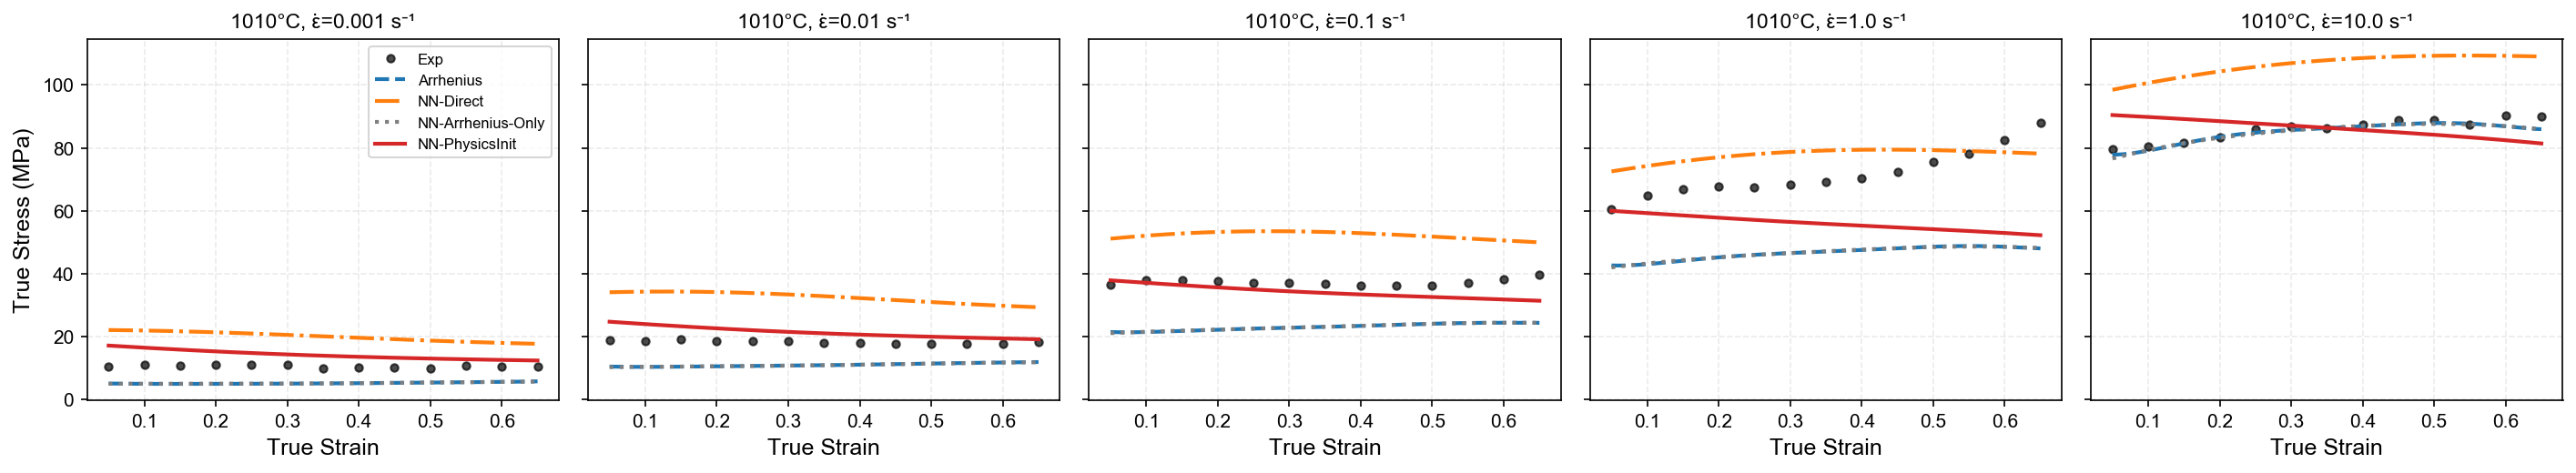

In [41]:
T_test_C = 1010
T_test_K = T_test_C + 273.15

rates_show = sorted(df_all['StrainRate'].unique())
eps_fine = np.linspace(float(eps_arr.min()), float(eps_arr.max()), 180)

fig, axes = plt.subplots(1, len(rates_show), figsize=(3.8 * len(rates_show), 3.6), sharey=True)
if len(rates_show) == 1:
    axes = [axes]

for ax, sr in zip(axes, rates_show):
    # experimental points (interpolated)
    sub = df_test[df_test['StrainRate'] == sr].sort_values('TrueStrain')
    ax.plot(sub['TrueStrain'].values, sub['FlowStress'].values, 'o', ms=4, color='black', alpha=0.7, label='Exp')

    # Arrhenius
    arr_curve = [arrhenius_predict(e, sr, T_test_K, poly_dict) for e in eps_fine]
    ax.plot(eps_fine, arr_curve, METHOD_STYLES['Arrhenius'], color=METHOD_COLORS['Arrhenius'], lw=2, label='Arrhenius')

    # NN curves
    Xc = prepare_features((np.full_like(eps_fine, T_test_K), np.full_like(eps_fine, sr), eps_fine), is_arrays=True)
    pd_curve = predict_nn(model_direct, Xc, norm_X, norm_y)
    pa_curve = predict_nn(model_arrhenius_only, Xc, norm_X, norm_y)
    pp_curve = predict_nn(model_physics, Xc, norm_X, norm_y)

    ax.plot(eps_fine, pd_curve, METHOD_STYLES['NN-Direct'], color=METHOD_COLORS['NN-Direct'], lw=2, label='NN-Direct')
    ax.plot(eps_fine, pa_curve, METHOD_STYLES['NN-Arrhenius-Only'], color=METHOD_COLORS['NN-Arrhenius-Only'], lw=2, label='NN-Arrhenius-Only')
    ax.plot(eps_fine, pp_curve, METHOD_STYLES['NN-PhysicsInit'], color=METHOD_COLORS['NN-PhysicsInit'], lw=2, label='NN-PhysicsInit')

    ax.set_title(f'1010°C, ε̇={sr} s⁻¹', fontsize=11)
    ax.set_xlabel('True Strain')
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel('True Stress (MPa)')
axes[0].legend(fontsize=8, loc='best')
plt.tight_layout()
save_fig(fig, 'extrapolation_curve_comparison_1010C_all_strain_rates')
plt.show()

---
## 8. 散点精度图（训练集 vs 1010°C 外推）

  Saved: /Users/bertonyang/project/chenglu/data_processor/4神经网络优化Arrhenius_指标优化/scatter_accuracy_training_vs_extrapolation_1010C_four_methods.png


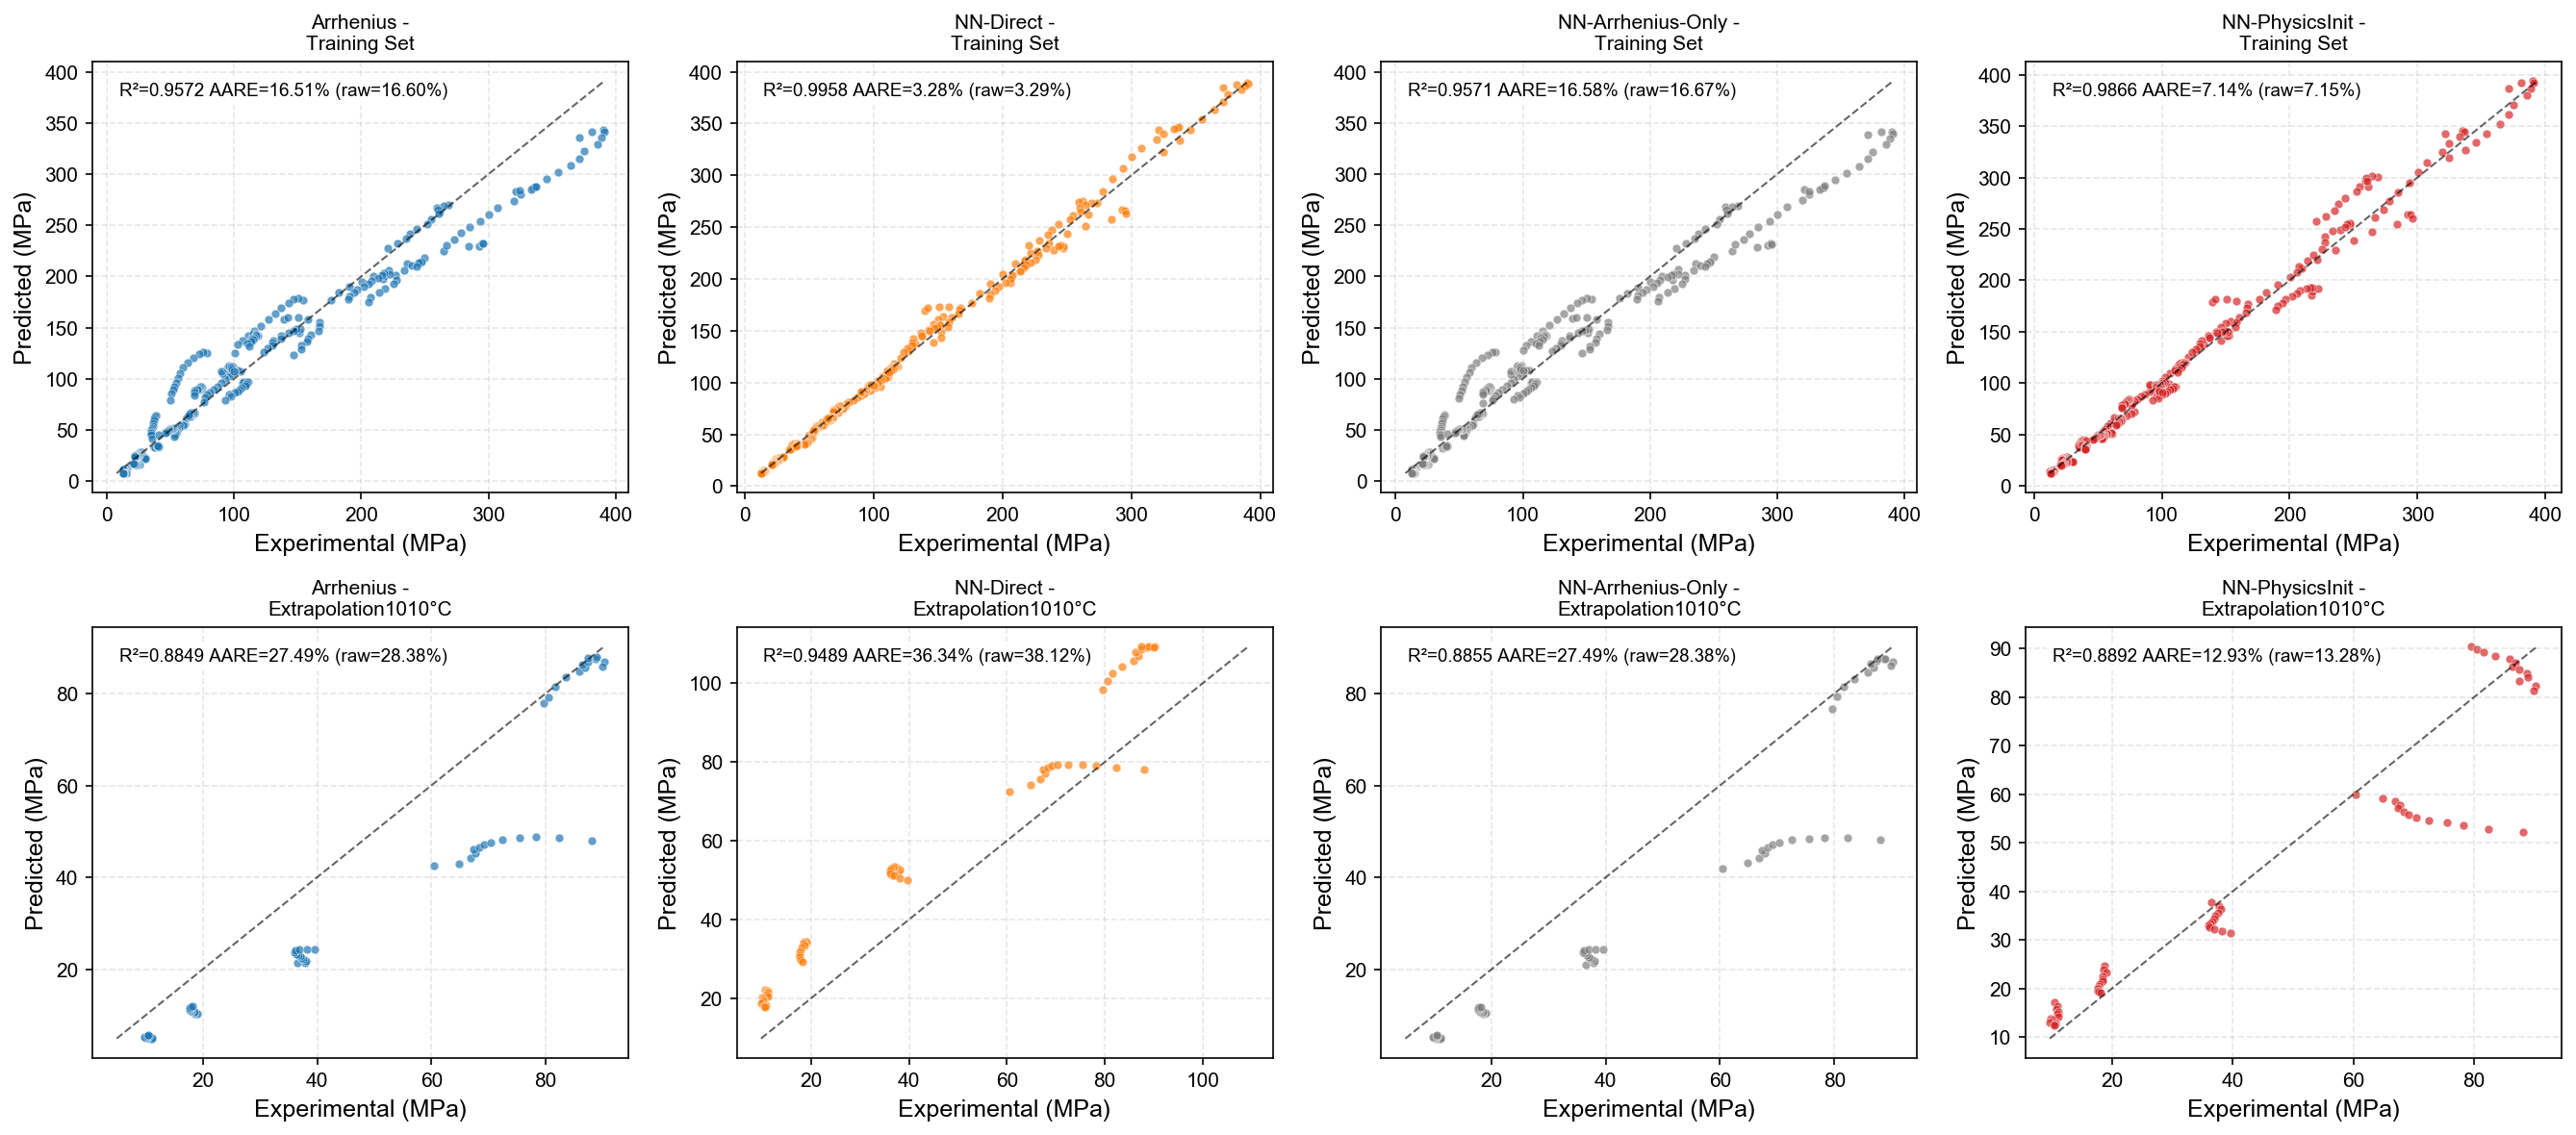

In [42]:
pred_map = {
    'Arrhenius': (arr_pred_train, arr_pred_test),
    'NN-Direct': (nn_direct_pred_train, nn_direct_pred_test),
    'NN-Arrhenius-Only': (nn_arronly_pred_train, nn_arronly_pred_test),
    'NN-PhysicsInit': (nn_physics_pred_train, nn_physics_pred_test),
}

def _scatter_ax(ax, yt, yp, title, method_name, eps=None):
    ax.scatter(yt, yp, s=18, alpha=0.7, color=METHOD_COLORS[method_name], edgecolor='white', linewidth=0.3)
    lo = min(float(np.min(yt)), float(np.min(yp)))
    hi = max(float(np.max(yt)), float(np.max(yp)))
    ax.plot([lo, hi], [lo, hi], '--', color='black', lw=1, alpha=0.6)

    r = evaluate_method(method_name, yt, yp, eps=eps)
    ax.text(0.05, 0.92, f"R²={r['R²']:.4f}\nAARE={r['AARE(%)']:.2f}%\n(raw={r['AARE_raw(%)']:.2f}%)",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none'))
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Experimental (MPa)')
    ax.set_ylabel('Predicted (MPa)')


fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for col, m in enumerate(METHOD_ORDER):
    yp_tr, yp_te = pred_map[m]
    _scatter_ax(axes[0, col], y_train_real, yp_tr, f'{m} - 训练集', m, eps=df_train['TrueStrain'].values)
    _scatter_ax(axes[1, col], y_test, yp_te, f'{m} - 外推1010°C', m, eps=df_test['TrueStrain'].values)

plt.tight_layout()
save_fig(fig, 'scatter_accuracy_training_vs_extrapolation_1010C_four_methods')
plt.show()

---
## 9. 消融柱状图：R² / AARE / RMSE（稳健AARE口径）

In [43]:
res_df = pd.DataFrame(results)

# 仅展示主指标列（稳健AARE）
summary = res_df[['方法', '数据集', 'R', 'R²', 'AARE(%)', 'RMSE(MPa)', 'AARE_raw(%)', 'N']].copy()
summary = summary.sort_values(['数据集', '方法'], key=lambda s: s.map({m: i for i, m in enumerate(METHOD_ORDER)}) if s.name == '方法' else s)
summary

,方法,数据集,R,R²,AARE(%),RMSE(MPa),AARE_raw(%),N
1,Arrhenius,外推(1010°C),0.940700,0.884916,27.493447,15.446026,28.383735,48
3,NN-Direct,外推(1010°C),0.974119,0.948907,36.337085,15.135525,38.124067,48
5,NN-Arrhenius-Only,外推(1010°C),0.941016,0.885510,27.486053,15.430842,28.377373,48
7,NN-PhysicsInit,外推(1010°C),0.942980,0.889211,12.926951,10.270397,13.281368,48
0,Arrhenius,训练集(800-980°C),0.978365,0.957199,16.507669,22.495143,16.599698,281
2,NN-Direct,训练集(800-980°C),0.997874,0.995752,3.281953,6.275556,3.291634,281
4,NN-Arrhenius-Only,训练集(800-980°C),0.978339,0.957147,16.580487,22.550937,16.672138,281
6,NN-PhysicsInit,训练集(800-980°C),0.993291,0.986627,7.136109,11.322607,7.146047,281


  Saved: /Users/bertonyang/project/chenglu/data_processor/4神经网络优化Arrhenius_指标优化/ablation_bar_R2_AARE_RMSE_four_methods.png


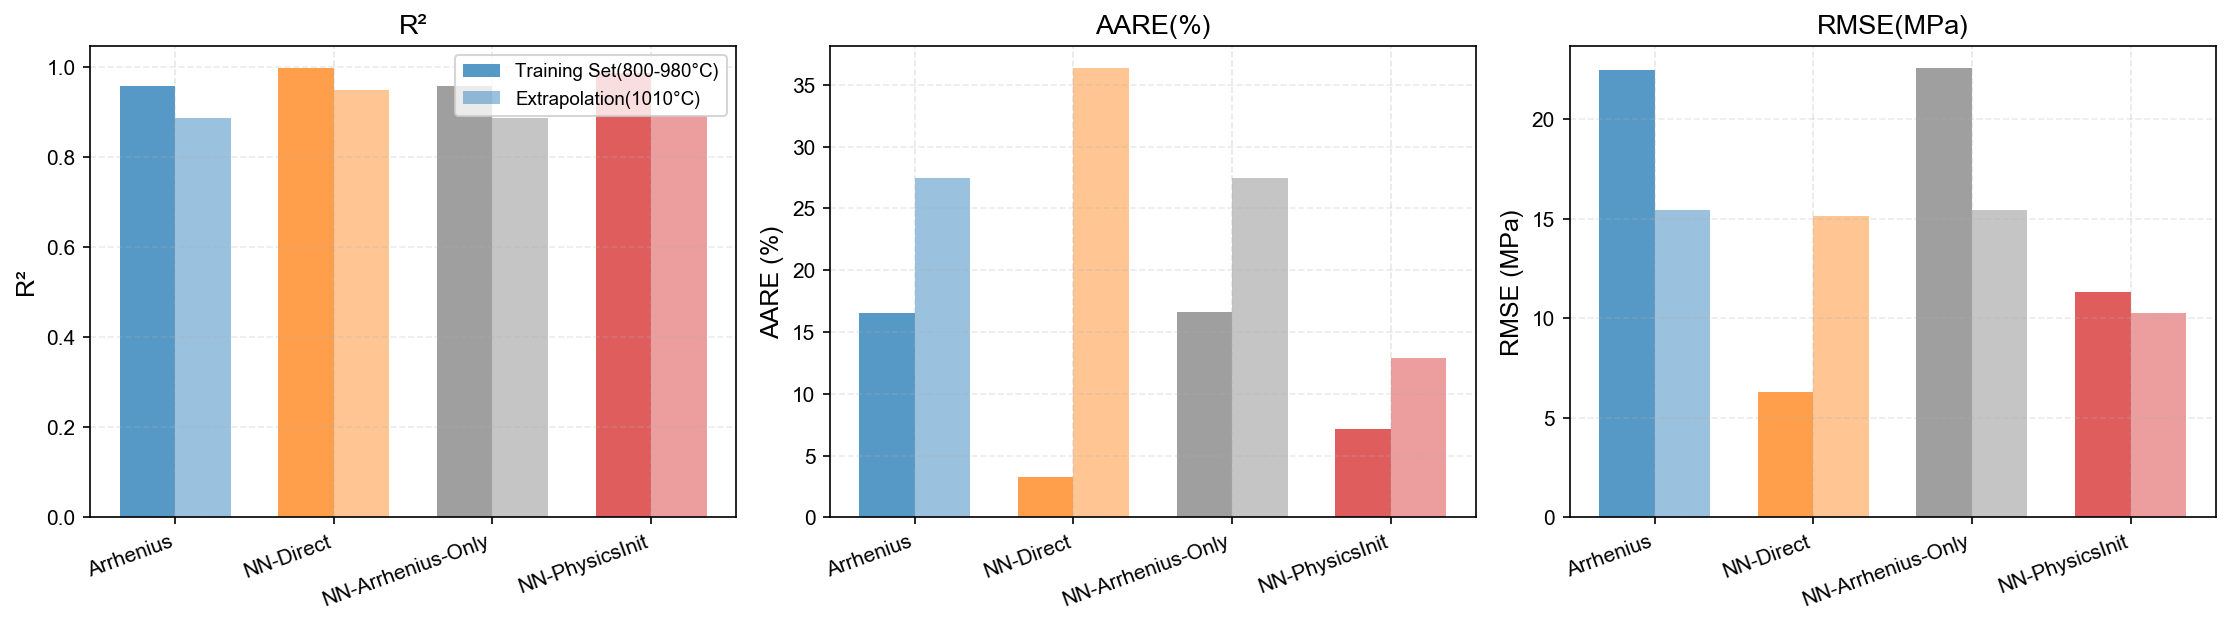

In [44]:
# 画柱状图：对比训练集 vs 外推1010°C（稳健AARE）
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
metrics = [('R²', 'R²'), ('AARE(%)', 'AARE (%)'), ('RMSE(MPa)', 'RMSE (MPa)')]

for ax, (metric, ylabel) in zip(axes, metrics):
    for i, ds in enumerate(['训练集(800-980°C)', '外推(1010°C)']):
        sub = summary[summary['数据集'] == ds].set_index('方法').loc[METHOD_ORDER]
        x = np.arange(len(METHOD_ORDER)) + (i - 0.5) * 0.35
        ax.bar(x, sub[metric].values, width=0.35,
               color=BAR_COLORS, alpha=0.75 if i == 0 else 0.45,
               label=ds if metric == 'R²' else None)

    ax.set_xticks(np.arange(len(METHOD_ORDER)))
    ax.set_xticklabels(METHOD_ORDER, rotation=20, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(metric)
    ax.grid(True, axis='y', alpha=0.25)

axes[0].legend(fontsize=9, loc='best')
plt.tight_layout()
save_fig(fig, 'ablation_bar_R2_AARE_RMSE_four_methods')
plt.show()

---
## 10. 补全图像（与原版并集 + 论文增强图）

本节仅新增图片输出，不改变已有图片名称与主流程逻辑。

  Saved: /Users/bertonyang/project/chenglu/data_processor/4神经网络优化Arrhenius_指标优化/training_curve_comparison_all_temperatures_all_strain_rates.png


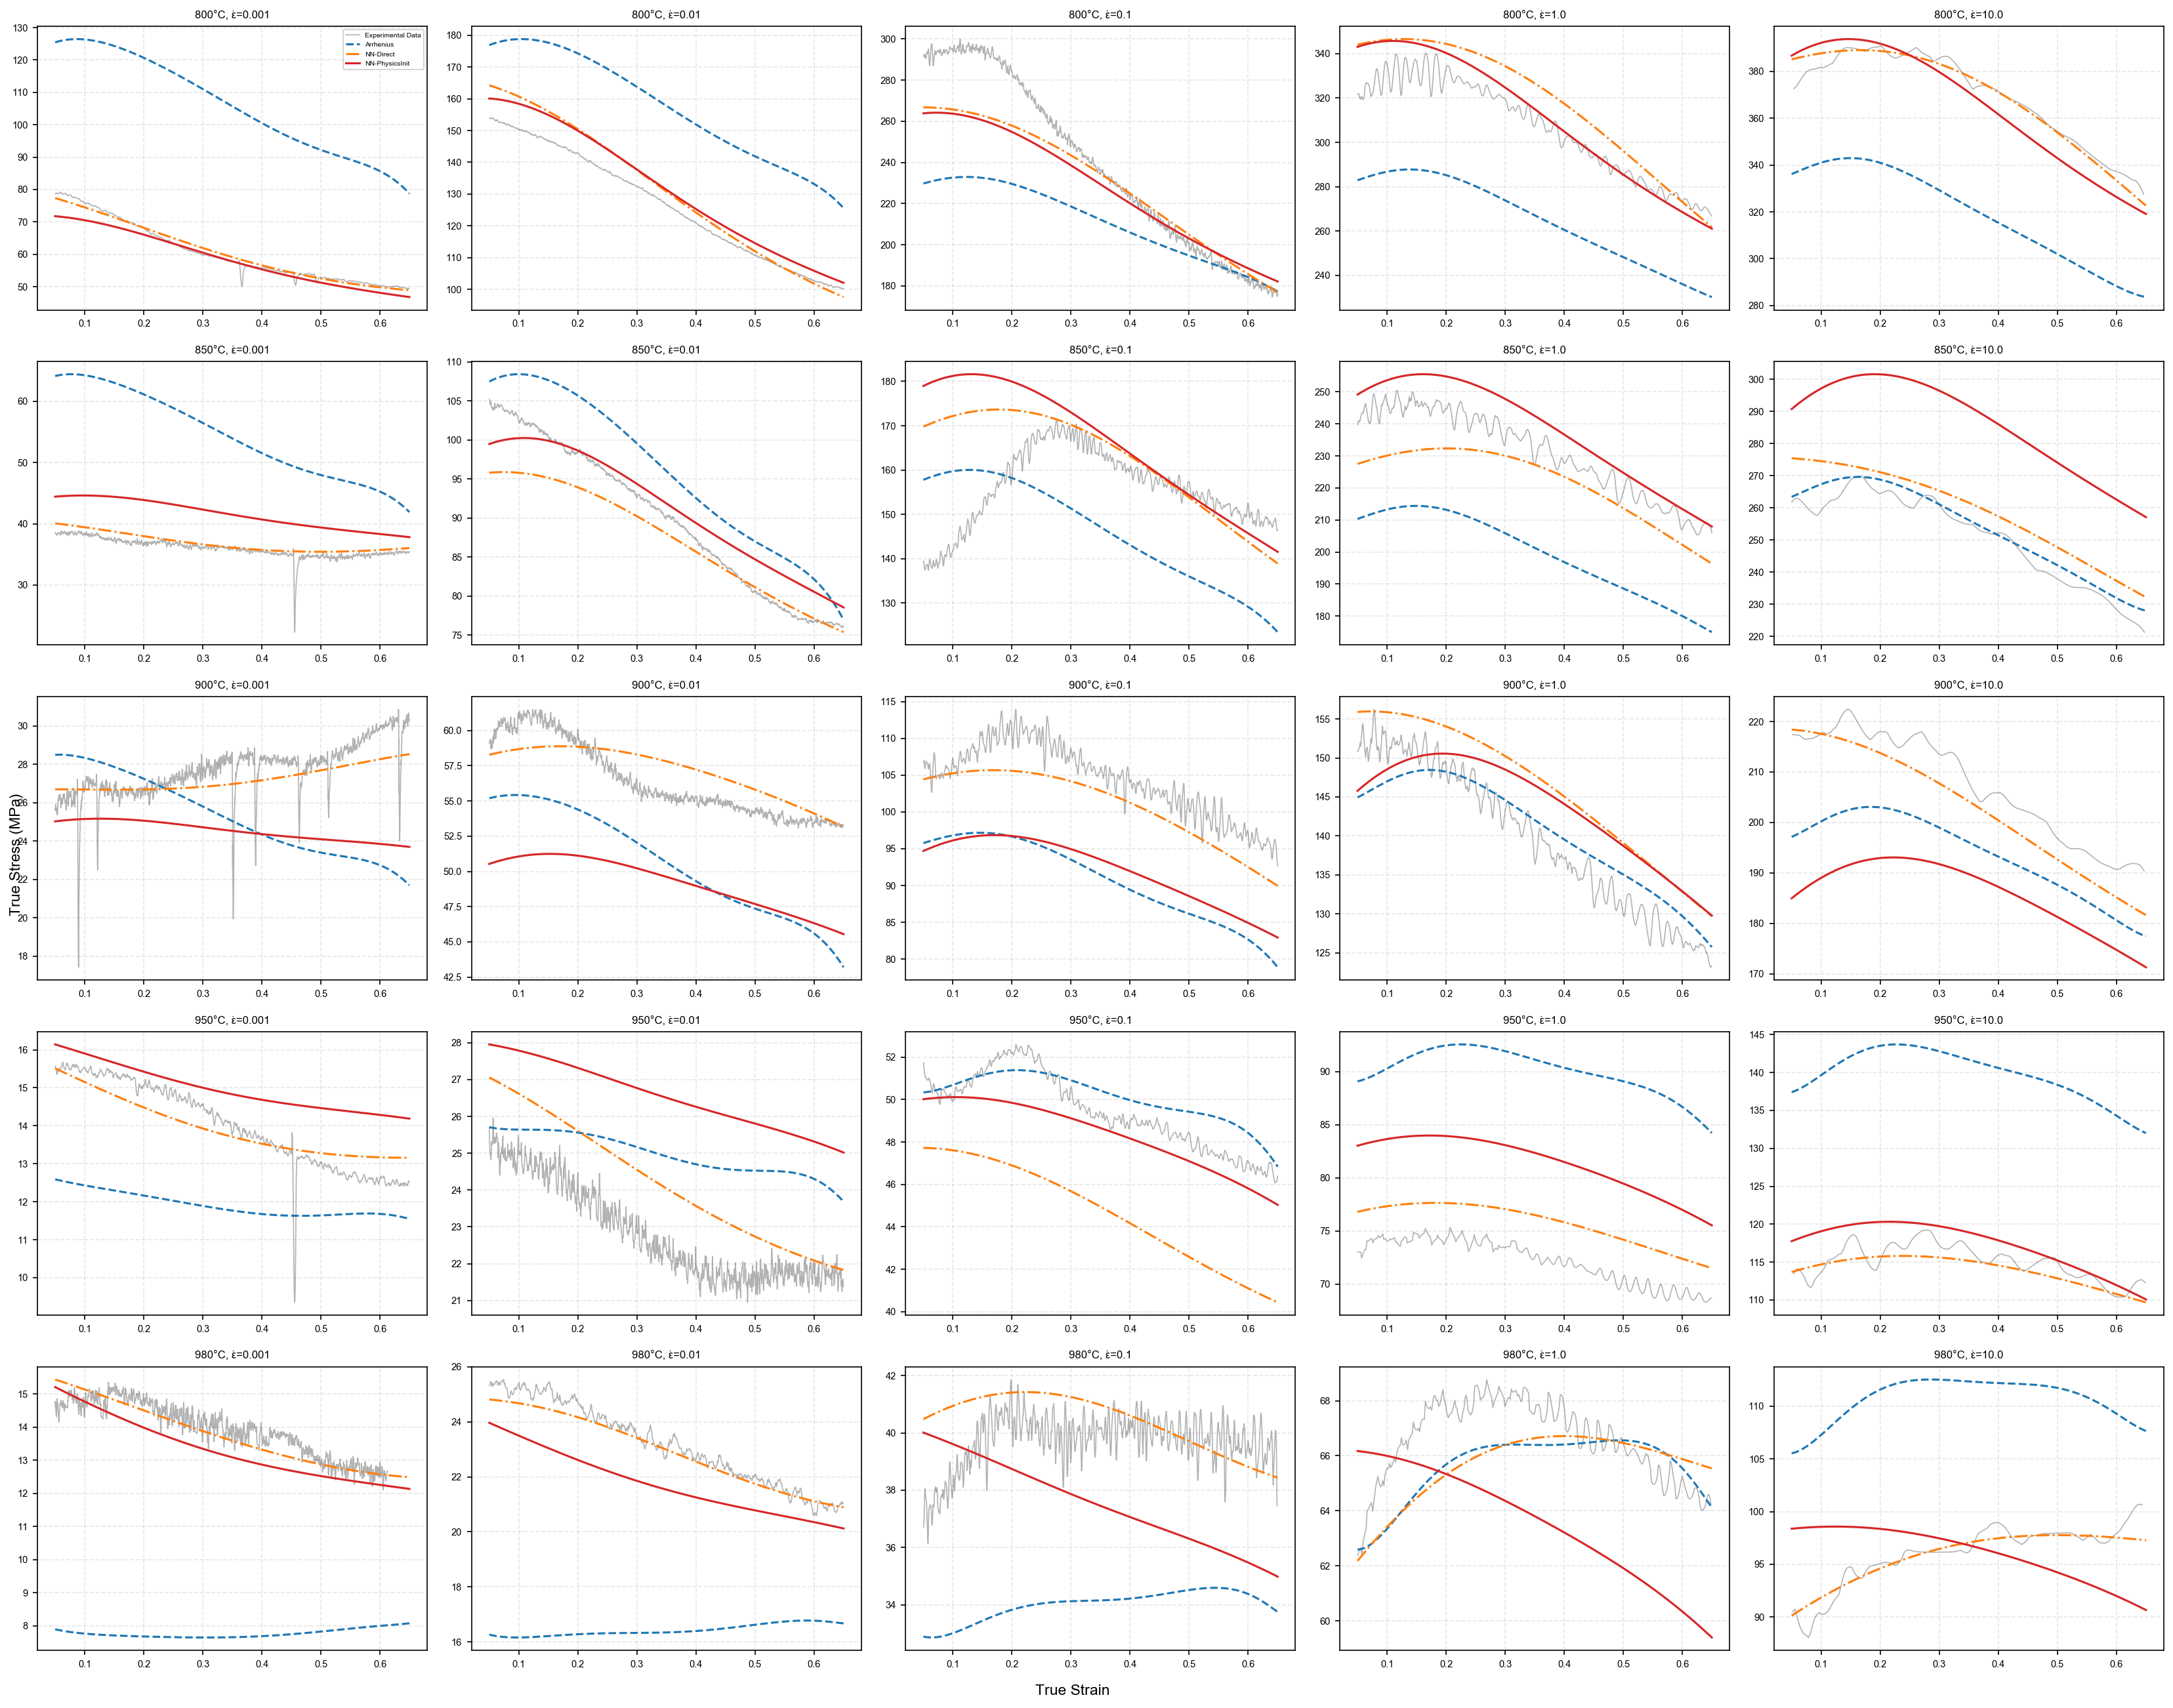

  Saved: /Users/bertonyang/project/chenglu/data_processor/4神经网络优化Arrhenius_指标优化/extrapolation_stress_trend_comparison_ann_oscillation_points_1010C.png


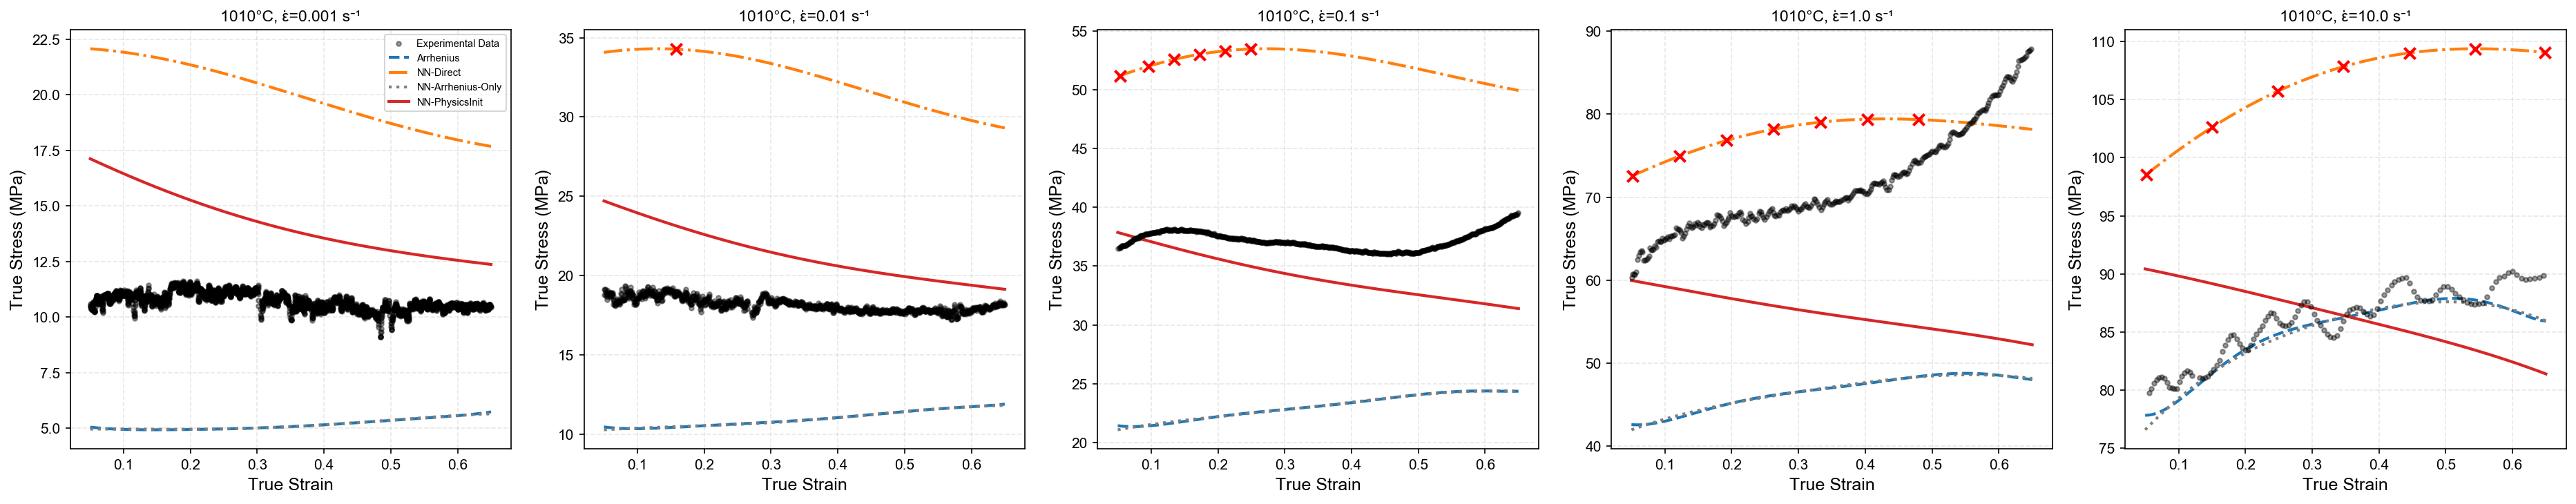

  Saved: /Users/bertonyang/project/chenglu/data_processor/4神经网络优化Arrhenius_指标优化/weight_distribution_histogram_global_three_nn_models.png


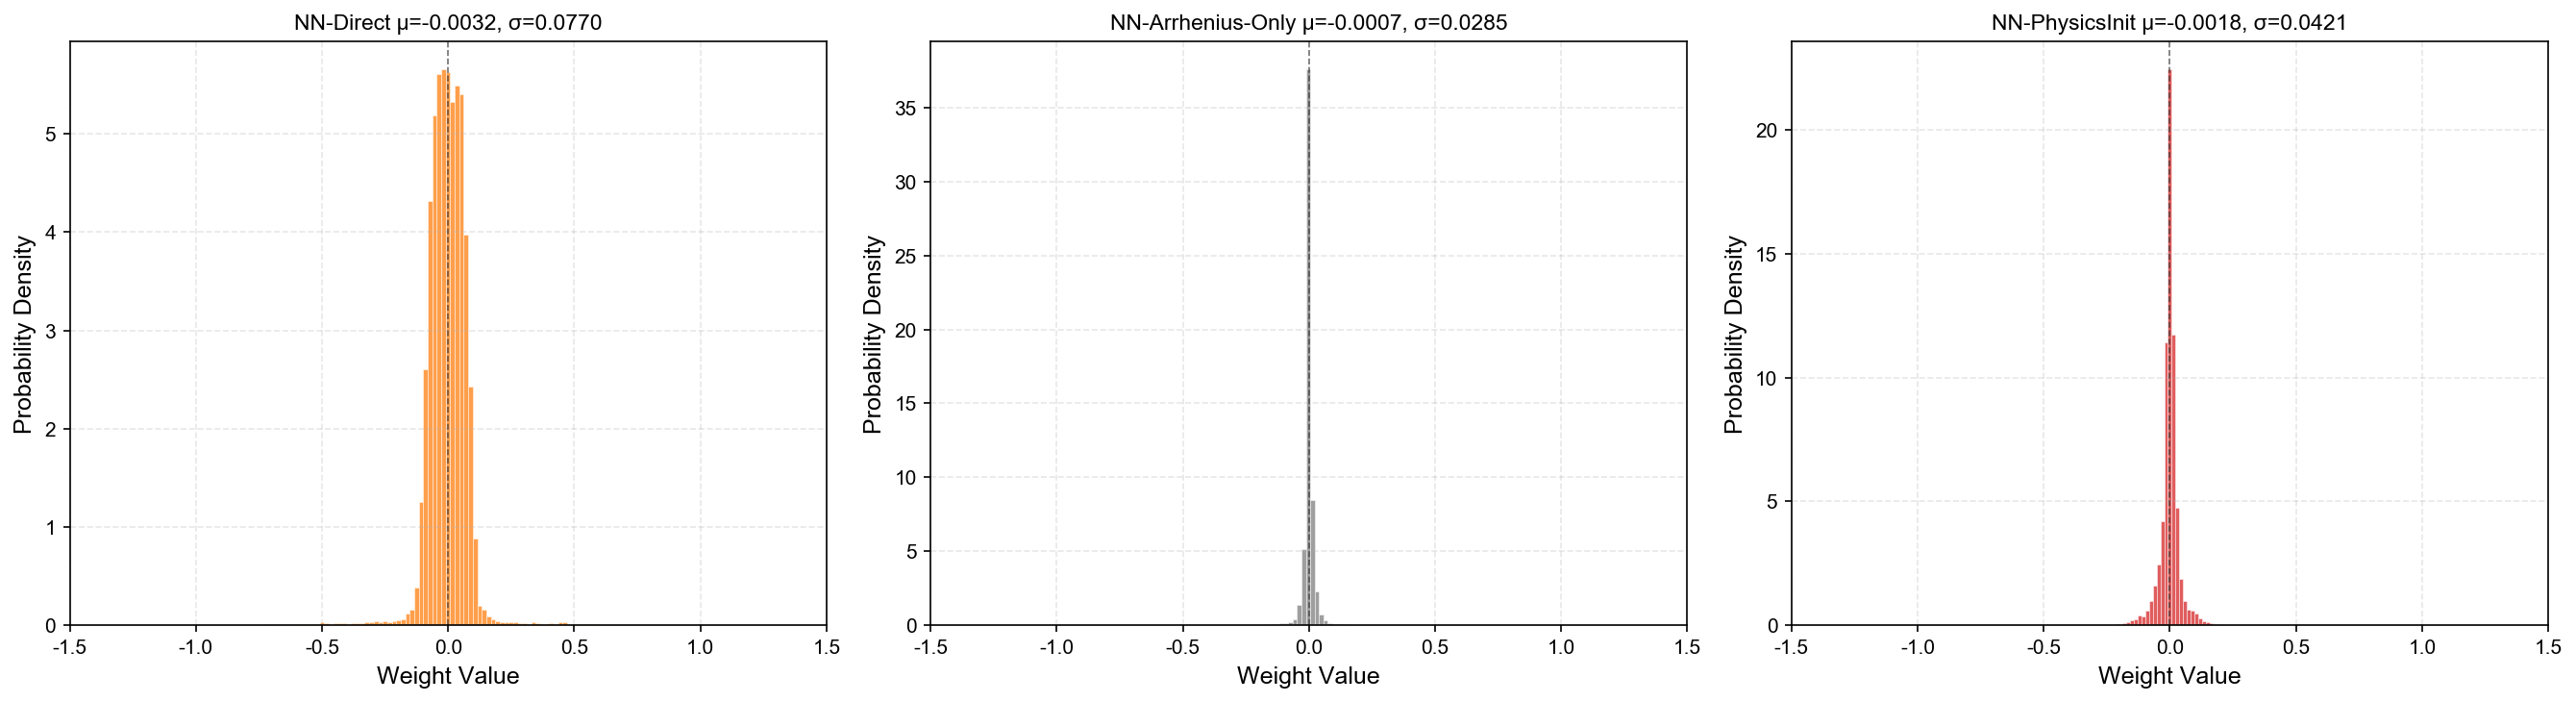

  Saved: /Users/bertonyang/project/chenglu/data_processor/4神经网络优化Arrhenius_指标优化/weight_distribution_histogram_by_layer_three_nn_models.png


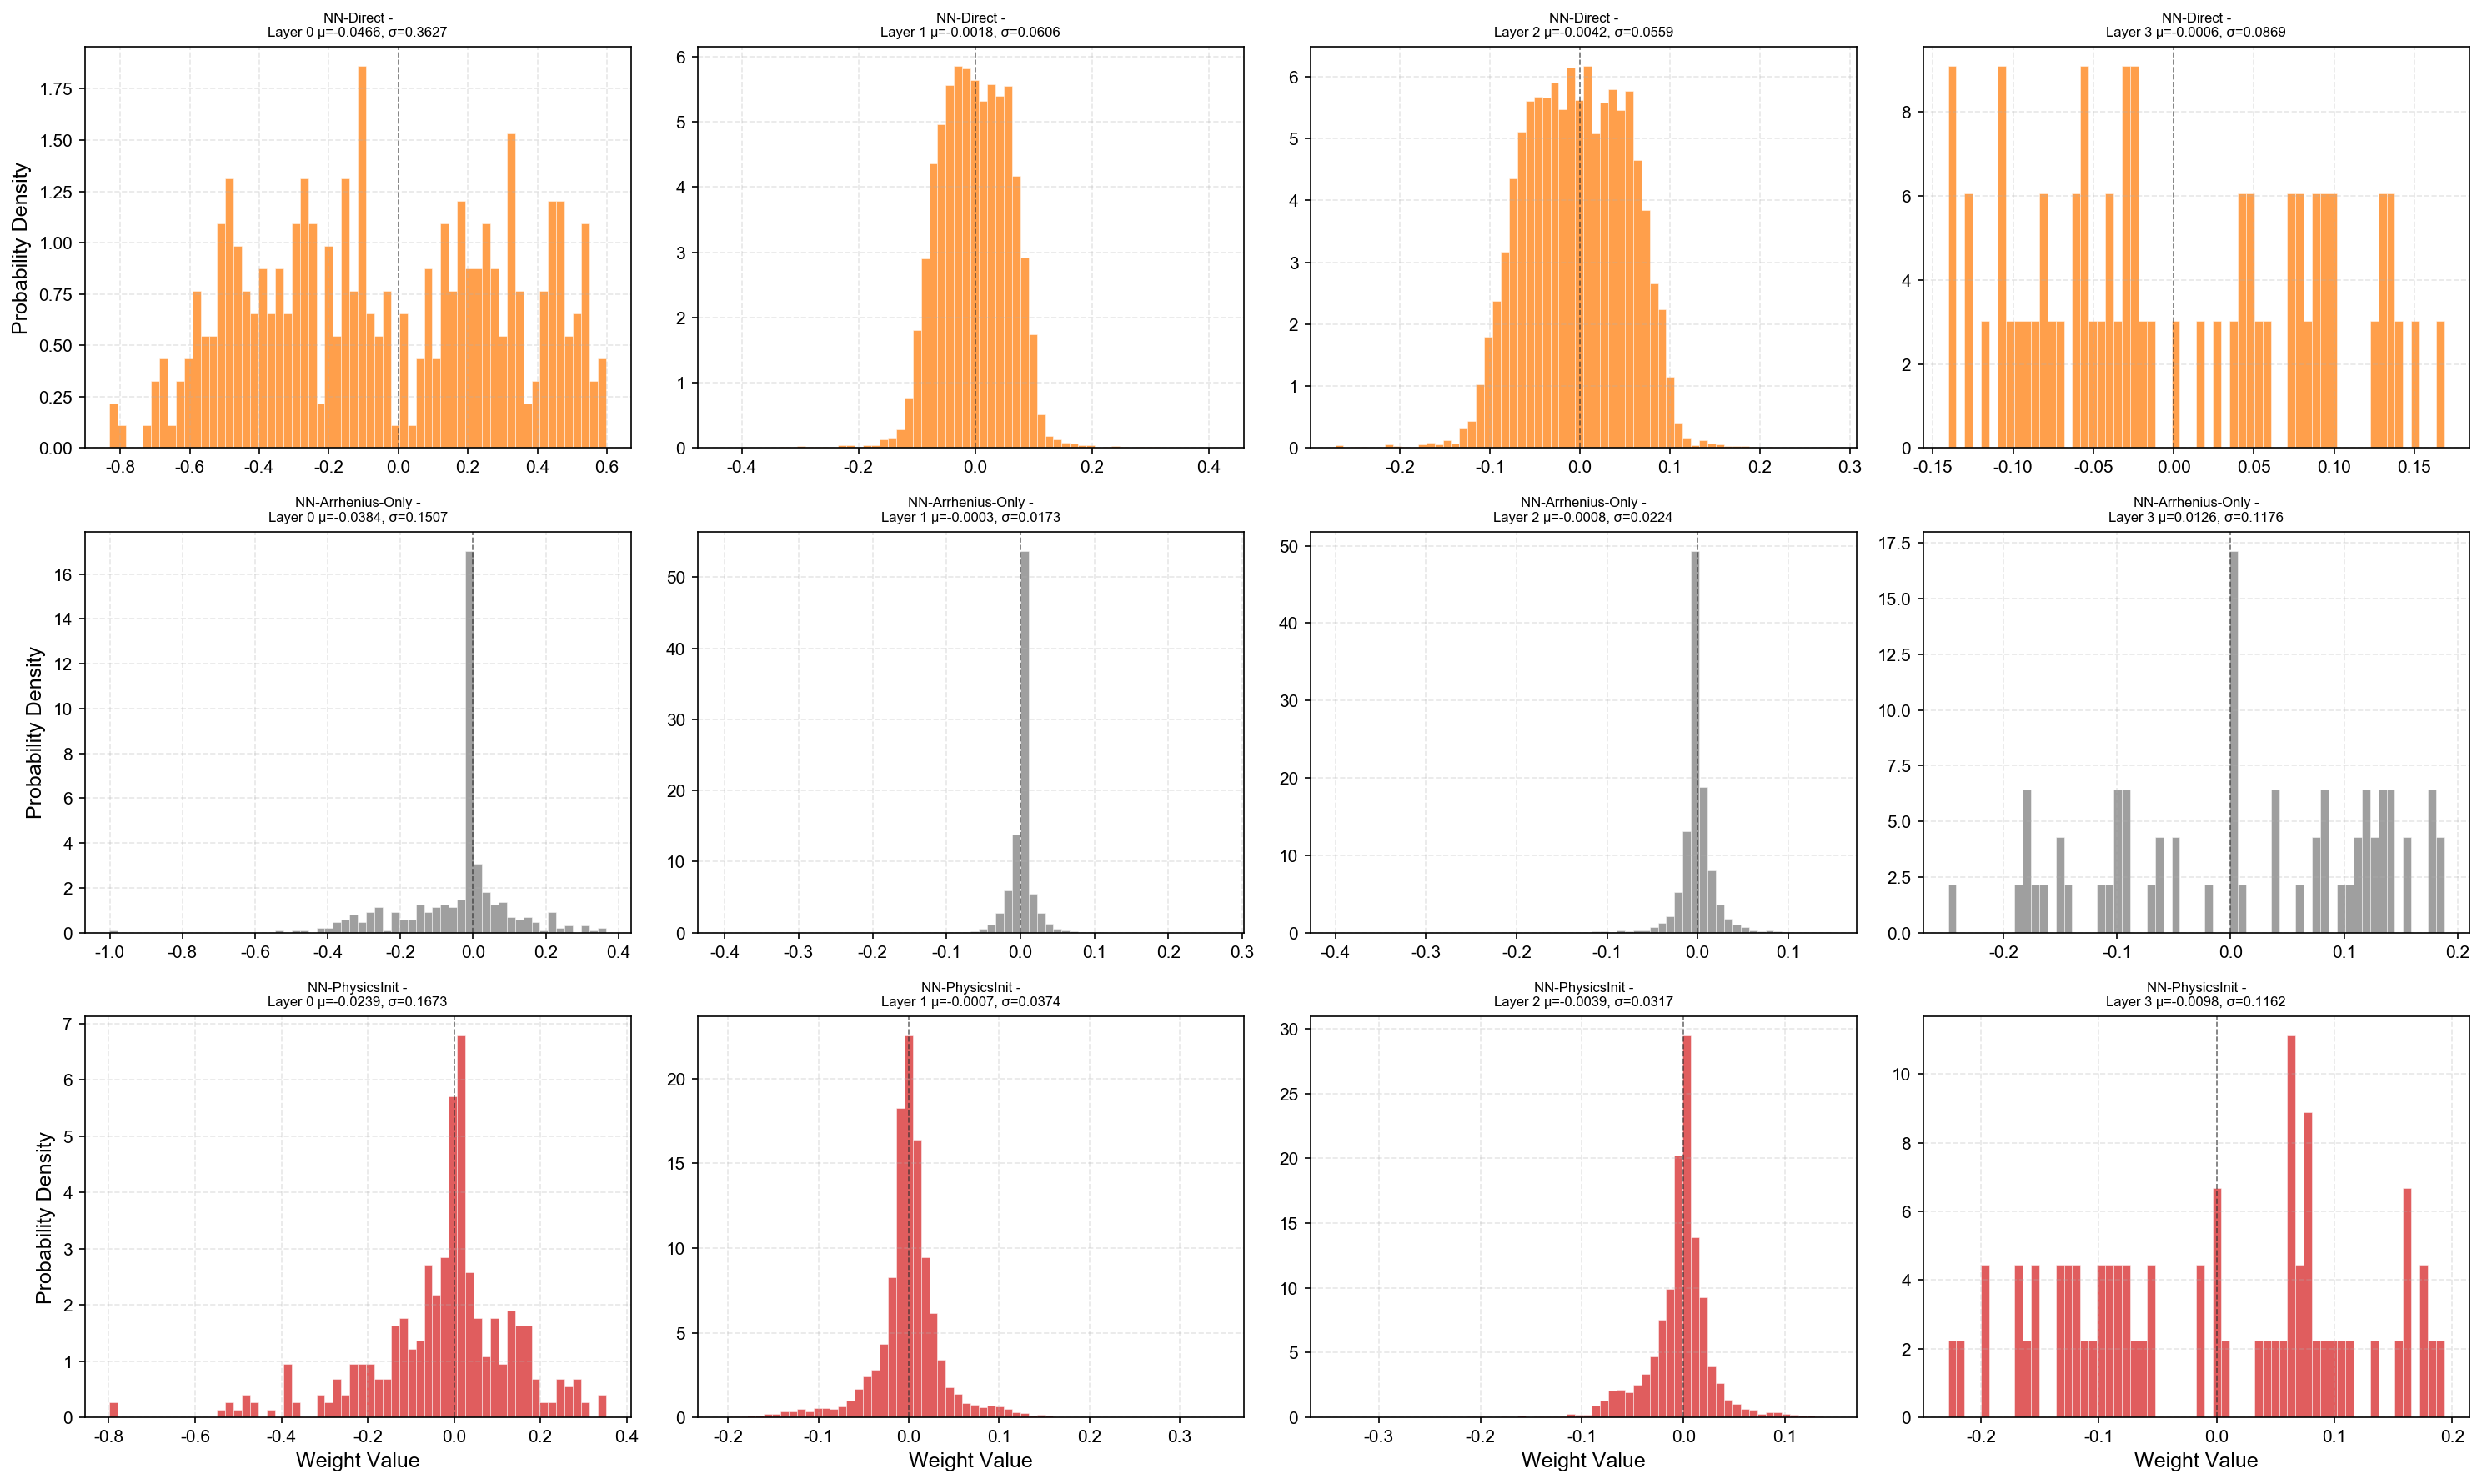

  Saved: /Users/bertonyang/project/chenglu/data_processor/4神经网络优化Arrhenius_指标优化/neural_network_hyperparameter_configuration.png


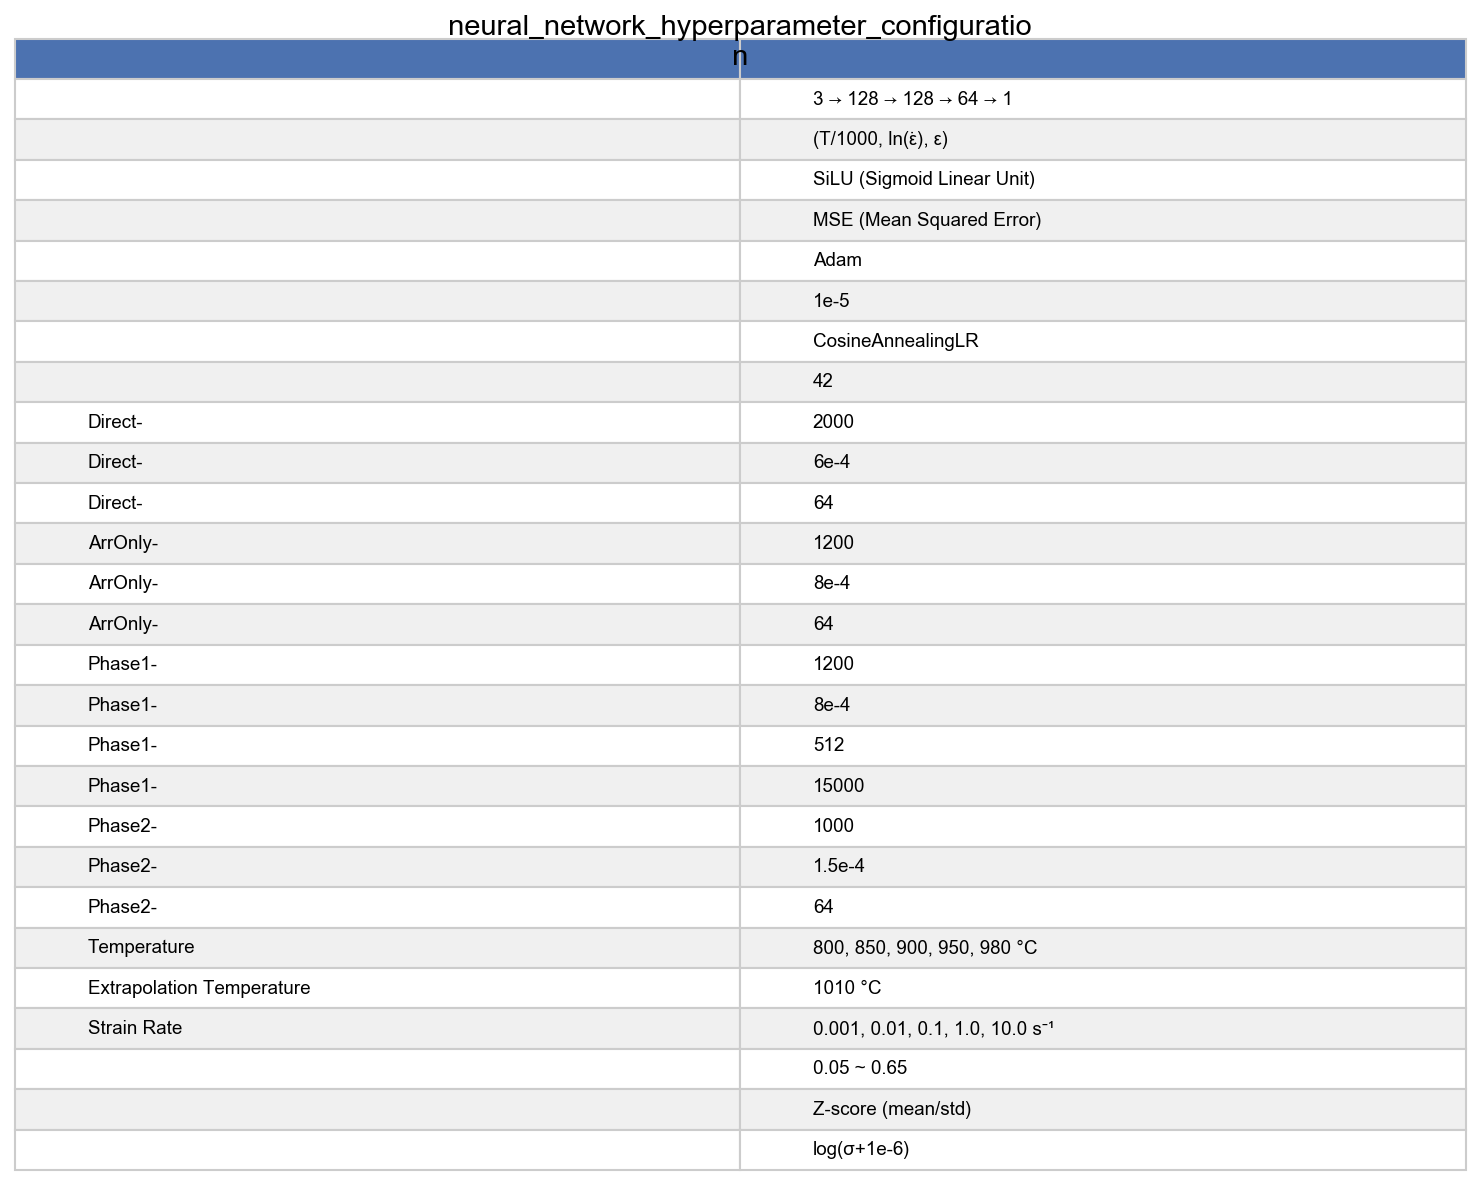

  Saved: /Users/bertonyang/project/chenglu/data_processor/4神经网络优化Arrhenius_指标优化/nn_physicsinit_training_pipeline_diagram.png


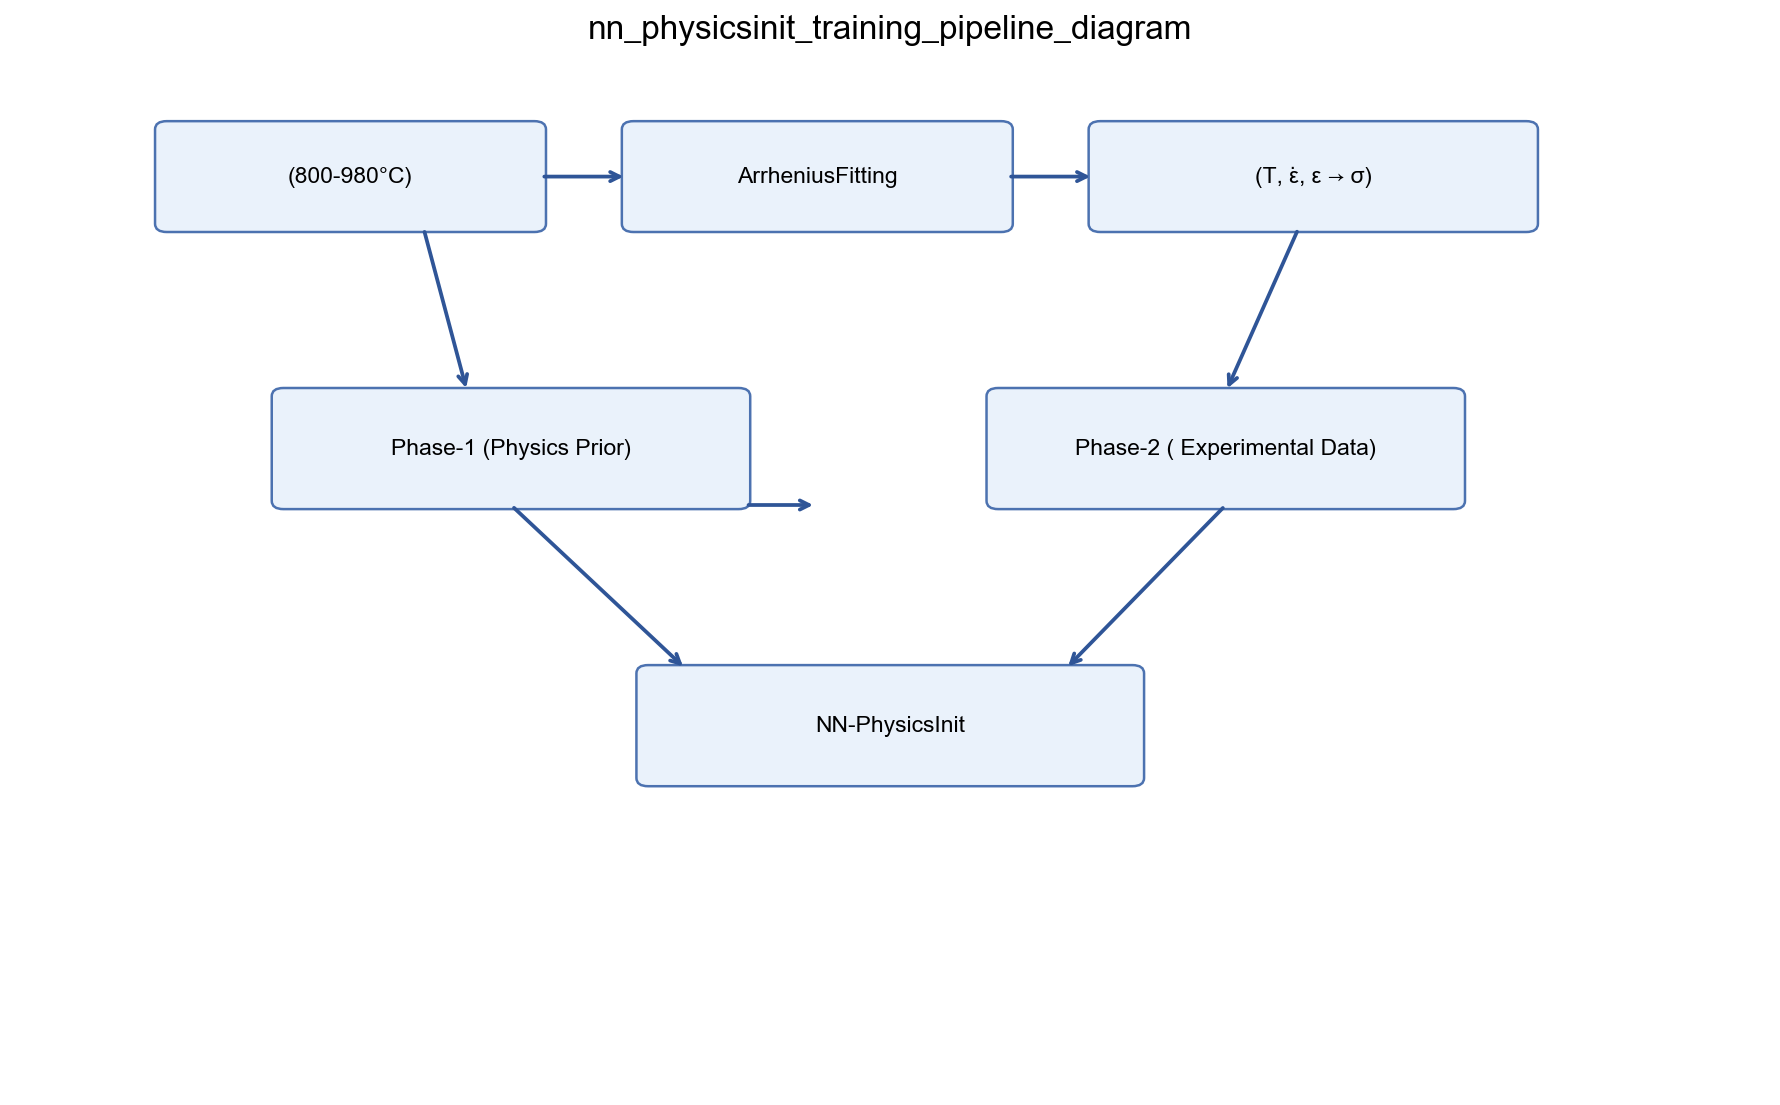

  Saved: /Users/bertonyang/project/chenglu/data_processor/4神经网络优化Arrhenius_指标优化/raw_data_coverage_count_heatmap_temperature_strain_rate.png


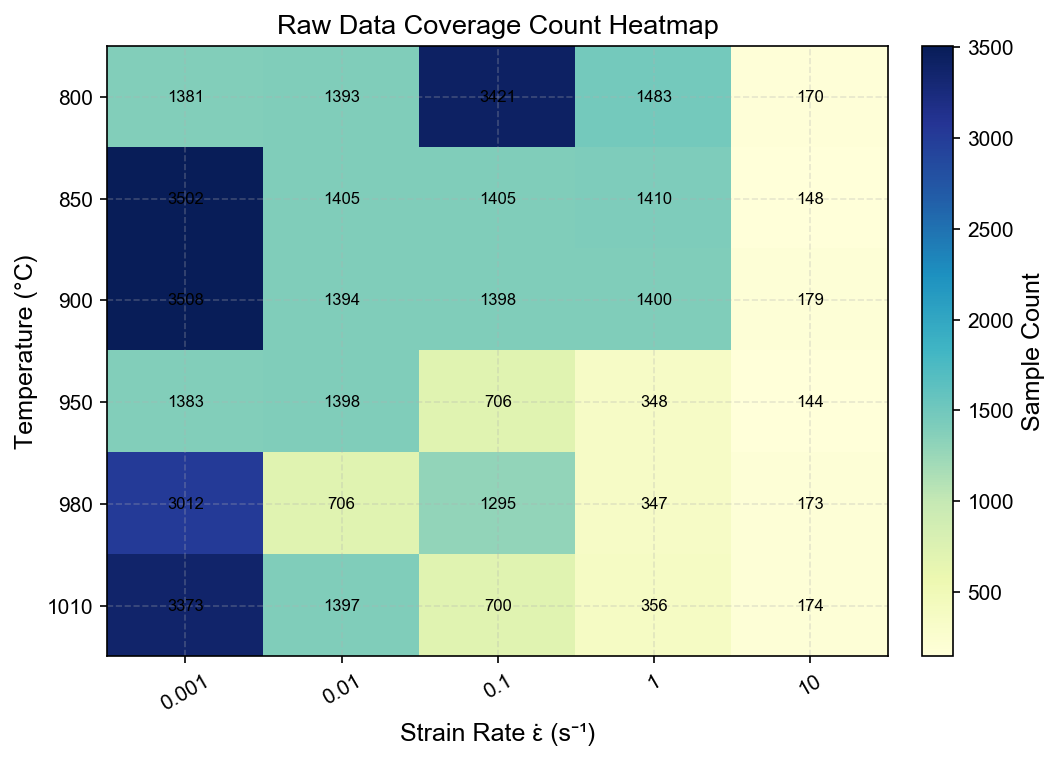

In [45]:
# ==================== 缺失图补全（保持已有结果不变，仅新增图片） ====================
# 1) 训练集曲线对比（原版同名图）
eps_plot = np.linspace(float(eps_arr.min()), float(eps_arr.max()), 100)
rates_show = sorted(df_all['StrainRate'].unique())

fig, axes = plt.subplots(len(TRAIN_TEMPS), len(rates_show), figsize=(4.5 * len(rates_show), 3.5 * len(TRAIN_TEMPS)))
for row, temp in enumerate(TRAIN_TEMPS):
    T_K_val = temp + 273.15
    for col, sr in enumerate(rates_show):
        ax = axes[row, col]
        exp = df_train_raw[(df_train_raw['Temperature'] == temp) & (df_train_raw['StrainRate'] == sr)].sort_values('TrueStrain')
        exp = exp[(exp['TrueStrain'] >= eps_arr.min()) & (exp['TrueStrain'] <= eps_arr.max())]
        if len(exp) > 0:
            ax.plot(exp['TrueStrain'], exp['FlowStress'], 'k-', alpha=0.3, linewidth=0.8, label='实验数据')

        arr_c = [arrhenius_predict(e, sr, T_K_val, poly_dict) for e in eps_plot]
        ax.plot(eps_plot, arr_c, METHOD_STYLES['Arrhenius'], color=METHOD_COLORS['Arrhenius'], linewidth=1.5, label='Arrhenius')

        for mname, model_obj in [('NN-Direct', model_direct), ('NN-PhysicsInit', model_physics)]:
            X_c = prepare_features((np.full_like(eps_plot, T_K_val), np.full_like(eps_plot, sr), eps_plot), is_arrays=True)
            p_c = predict_nn(model_obj, X_c, norm_X, norm_y)
            ax.plot(eps_plot, p_c, METHOD_STYLES[mname], color=METHOD_COLORS[mname], linewidth=1.5, label=mname)

        ax.set_title(f'{temp}°C, ε̇={sr}', fontsize=8)
        ax.tick_params(labelsize=7)
        if row == 0 and col == 0:
            ax.legend(fontsize=5)

fig.supxlabel('True Strain', fontsize=11)
fig.supylabel('True Stress (MPa)', fontsize=11)
plt.tight_layout()
save_fig(fig, 'training_curve_comparison_all_temperatures_all_strain_rates')
plt.show()

# 2) 外推区域应力趋势对比 + ANN震荡点标注（原版同名图）
eps_fine = np.linspace(float(eps_arr.min()), float(eps_arr.max()), 300)
fig, axes = plt.subplots(1, len(rates_show), figsize=(5 * len(rates_show), 5))
T_test_K = 1010 + 273.15

for ax, sr in zip(axes, rates_show):
    exp = df_test_raw[(df_test_raw['StrainRate'] == sr)].sort_values('TrueStrain')
    exp = exp[(exp['TrueStrain'] >= eps_arr.min()) & (exp['TrueStrain'] <= eps_arr.max())]
    if len(exp) > 0:
        ax.scatter(exp['TrueStrain'], exp['FlowStress'], c='black', s=10, alpha=0.4, label='实验数据', zorder=5)

    ac = np.array([arrhenius_predict(e, sr, T_test_K, poly_dict) for e in eps_fine])
    ax.plot(eps_fine, ac, METHOD_STYLES['Arrhenius'], color=METHOD_COLORS['Arrhenius'], lw=2, label='Arrhenius')

    for mname, model_obj in [('NN-Direct', model_direct), ('NN-Arrhenius-Only', model_arrhenius_only), ('NN-PhysicsInit', model_physics)]:
        Xc = prepare_features((np.full_like(eps_fine, T_test_K), np.full_like(eps_fine, sr), eps_fine), is_arrays=True)
        pc = predict_nn(model_obj, Xc, norm_X, norm_y)
        ax.plot(eps_fine, pc, METHOD_STYLES[mname], color=METHOD_COLORS[mname], lw=2, label=mname)

        if mname == 'NN-Direct':
            d2 = np.diff(pc, n=2)
            osc_threshold = np.std(d2) * 2.0
            osc_indices = np.where(np.abs(d2) > osc_threshold)[0] + 1
            if len(osc_indices) > 0:
                step = max(1, len(osc_indices) // 6)
                osc_show = osc_indices[::step]
                ax.scatter(eps_fine[osc_show], pc[osc_show], marker='x', c='red', s=60, linewidths=2, zorder=10, label='NN-Direct 震荡点')

    ax.set_title(f'1010°C, ε̇={sr} s⁻¹', fontsize=11)
    ax.set_xlabel('True Strain')
    ax.set_ylabel('True Stress (MPa)')
    if sr == rates_show[0]:
        ax.legend(fontsize=7, loc='best')

plt.tight_layout()
save_fig(fig, 'extrapolation_stress_trend_comparison_ann_oscillation_points_1010C')
plt.show()

# 3) 权重分布直方图（原版同名图）
def get_all_weights(model):
    ws = []
    for _, param in model.named_parameters():
        ws.extend(param.detach().cpu().flatten().tolist())
    return np.asarray(ws, dtype=np.float32)

def get_layer_weights(model):
    layer_w = {}
    layer_idx = 0
    for name, param in model.named_parameters():
        if 'weight' in name:
            layer_w[f'Layer {layer_idx}'] = np.asarray(param.detach().cpu().flatten().tolist(), dtype=np.float32)
            layer_idx += 1
    return layer_w

nn_models = {
    'NN-Direct': model_direct,
    'NN-Arrhenius-Only': model_arrhenius_only,
    'NN-PhysicsInit': model_physics,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (mname, model_obj) in zip(axes, nn_models.items()):
    w = get_all_weights(model_obj)
    ax.hist(w, bins=80, alpha=0.75, color=METHOD_COLORS[mname], edgecolor='white', linewidth=0.3, density=True)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(f'{mname}\nμ={w.mean():.4f}, σ={w.std():.4f}', fontsize=11)
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Probability Density')
    ax.set_xlim(-1.5, 1.5)
plt.tight_layout()
save_fig(fig, 'weight_distribution_histogram_global_three_nn_models')
plt.show()

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for row, (mname, model_obj) in enumerate(nn_models.items()):
    lw = get_layer_weights(model_obj)
    for col, (lname, ww) in enumerate(lw.items()):
        ax = axes[row, col]
        ax.hist(ww, bins=60, alpha=0.75, color=METHOD_COLORS[mname], edgecolor='white', linewidth=0.3, density=True)
        ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.set_title(f'{mname} - {lname}\nμ={ww.mean():.4f}, σ={ww.std():.4f}', fontsize=8)
        if row == 2:
            ax.set_xlabel('Weight Value')
        if col == 0:
            ax.set_ylabel('Probability Density')
plt.tight_layout()
save_fig(fig, 'weight_distribution_histogram_by_layer_three_nn_models')
plt.show()

# 4) 神经网络超参数配置表（原版同名图）
config_table = {
    '网络结构': '3 → 128 → 128 → 64 → 1',
    '输入特征': '(T/1000, ln(ε̇), ε)',
    '激活函数': 'SiLU (Sigmoid Linear Unit)',
    '损失函数': 'MSE (Mean Squared Error)',
    '优化器': 'Adam',
    '权重衰减': '1e-5',
    '学习率调度器': 'CosineAnnealingLR',
    '随机种子': str(SEED),
    '--- NN-Direct ---': '',
    'Direct-训练轮次': '2000',
    'Direct-学习率': '6e-4',
    'Direct-批大小': '64',
    '--- NN-Arrhenius-Only ---': '',
    'ArrOnly-训练轮次': '1200',
    'ArrOnly-学习率': '8e-4',
    'ArrOnly-批大小': '64',
    '--- NN-PhysicsInit ---': '',
    'Phase1-预训练轮次': '1200',
    'Phase1-学习率': '8e-4',
    'Phase1-批大小': '512',
    'Phase1-合成数据量': '15000',
    'Phase2-微调轮次': '1000',
    'Phase2-学习率': '1.5e-4',
    'Phase2-批大小': '64',
    '--- 数据 ---': '',
    '训练温度': '800, 850, 900, 950, 980 °C',
    '外推测试温度': '1010 °C',
    '应变速率': '0.001, 0.01, 0.1, 1.0, 10.0 s⁻¹',
    '应变范围': f'{float(eps_arr.min()):.2f} ~ {float(eps_arr.max()):.2f}',
    '特征标准化': 'Z-score (mean/std)',
    '目标变换': 'log(σ+1e-6)' if USE_LOG_STRESS_TARGET else 'stress 直接回归',
}

fig, ax = plt.subplots(figsize=(10, 8))
ax.axis('off')
rows = []
for k, v in config_table.items():
    if not k.startswith('---') and v:
        rows.append([k, v])
table = ax.table(cellText=rows, colLabels=['', ''], loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#4C72B0')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f0f0f0')
    cell.set_edgecolor('#cccccc')
ax.set_title('neural_network_hyperparameter_configuration', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
save_fig(fig, 'neural_network_hyperparameter_configuration')
plt.show()

# 5) NN-PhysicsInit 训练流程架构图（原版同名图，简洁版）
fig, ax = plt.subplots(figsize=(12, 7.5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.axis('off')

steps = [
    (1.0, 8.4, 2.6, 1.0, '训练数据\n(800-980°C)'),
    (4.2, 8.4, 2.6, 1.0, 'Arrhenius拟合\n生成先验'),
    (7.4, 8.4, 3.0, 1.0, '合成数据\n(T, ε̇, ε → σ)'),
    (1.8, 5.7, 3.2, 1.1, 'Phase-1 预训练\n(Physics Prior)'),
    (6.7, 5.7, 3.2, 1.1, 'Phase-2 微调\n(真实实验数据)'),
    (4.3, 3.0, 3.4, 1.1, '最终模型\nNN-PhysicsInit'),
]

for x, y, w, h, txt in steps:
    box = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.04,rounding_size=0.08', linewidth=1.2, edgecolor='#4C72B0', facecolor='#EAF2FB')
    ax.add_patch(box)
    ax.text(x + w / 2, y + h / 2, txt, ha='center', va='center', fontsize=11)

arrows = [
    ((3.6, 8.9), (4.2, 8.9)),
    ((6.8, 8.9), (7.4, 8.9)),
    ((2.8, 8.4), (3.1, 6.8)),
    ((8.8, 8.4), (8.3, 6.8)),
    ((5.0, 5.7), (5.5, 5.7)),
    ((8.3, 5.7), (7.2, 4.1)),
    ((3.4, 5.7), (4.6, 4.1)),
]
for (x1, y1), (x2, y2) in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle='->', lw=1.8, color='#2F5597'))

ax.set_title('nn_physicsinit_training_pipeline_diagram', fontsize=16, fontweight='bold', pad=12)
plt.tight_layout()
save_fig(fig, 'nn_physicsinit_training_pipeline_diagram')
plt.show()

# 6) 额外基础图：原始数据覆盖分布热图（新增）
cov = df_all.pivot_table(index='Temperature', columns='StrainRate', values='FlowStress', aggfunc='count').fillna(0)
fig, ax = plt.subplots(figsize=(7.2, 5.2))
im = ax.imshow(cov.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(np.arange(len(cov.columns)))
ax.set_xticklabels([f'{c:g}' for c in cov.columns], rotation=30)
ax.set_yticks(np.arange(len(cov.index)))
ax.set_yticklabels([f'{int(t)}' for t in cov.index])
ax.set_xlabel('Strain Rate ε̇ (s⁻¹)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Raw Data Coverage Count Heatmap')
for i in range(cov.shape[0]):
    for j in range(cov.shape[1]):
        ax.text(j, i, int(cov.values[i, j]), ha='center', va='center', fontsize=8, color='black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='样本数')
plt.tight_layout()
save_fig(fig, 'raw_data_coverage_count_heatmap_temperature_strain_rate')
plt.show()